Group member 1: Viola, Bätz

Group member 2: Leonard, Batten-Wölfl

Group member 3: Zeynep Dakduklu

# Task 1: Estimating Transportation Costs

In this notebook, we develop a method to estimate the transportation costs $c_{ij}$ from each cash center $i$ to each customer region $j$.

Our approach takes into account:
- The **demand** of each region ($d_j$)
- The **productivity** of each region ($p_j$, represented by `minutesPerStop` $m_j = 1/p_j$)
- The **travel time** from warehouse $i$ to region $j$ ($t_{ij}$)

We validate our estimates against the benchmark costs provided in `shifts_with_costs.csv`.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn pulp highspy -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import pulp as pl

## 1. Load and Explore the Data

In [3]:
# Load all datasets
warehouses = pd.read_csv(
    'https://raw.githubusercontent.com/D3IP-SS25/data-driven-scm-dataset/refs/heads/main/data/warehouses.csv',
    index_col='warehouseID'
)

regions = pd.read_csv(
    'https://raw.githubusercontent.com/D3IP-SS25/data-driven-scm-dataset/refs/heads/main/data/regions.csv',
    index_col='regionID'
)

# Raw shifts data (travel times and other operational info)
shifts_raw = pd.read_csv(
    'https://raw.githubusercontent.com/D3IP-SS25/data-driven-scm-dataset/refs/heads/main/data/shifts.csv',
    index_col=['warehouseID', 'regionID']
)

# Benchmark data with pre-computed transportation costs
shifts_benchmark = pd.read_csv(
    'https://raw.githubusercontent.com/D3IP-SS25/data-driven-scm-dataset/refs/heads/main/data/shifts_with_costs.csv',
    index_col=['warehouseID', 'regionID']
)

In [4]:
# Explore column names and data shapes
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"\nWarehouses: {warehouses.shape[0]} rows, columns: {warehouses.columns.tolist()}")
print(f"Regions:    {regions.shape[0]} rows, columns: {regions.columns.tolist()}")
print(f"Shifts (raw):       {shifts_raw.shape[0]} rows, columns: {shifts_raw.columns.tolist()}")
print(f"Shifts (benchmark): {shifts_benchmark.shape[0]} rows, columns: {shifts_benchmark.columns.tolist()}")

print("\n--- Warehouses (first 3 rows) ---")
display(warehouses.head(3))
print("\n--- Regions (first 3 rows) ---")
display(regions.head(3))
print("\n--- Shifts raw (first 5 rows) ---")
display(shifts_raw.head(5))
print("\n--- Shifts benchmark (first 5 rows) ---")
display(shifts_benchmark.head(5))

DATA OVERVIEW

Warehouses: 42 rows, columns: ['city', 'fixedCosts', 'lat', 'lon']
Regions:    515 rows, columns: ['zipCode', 'city', 'lat', 'lon', 'yearlyDemand', 'minutesPerStop']
Shifts (raw):       21630 rows, columns: ['transportationCosts', 'travelTime']
Shifts (benchmark): 21630 rows, columns: ['transportationCosts', 'travelTime']

--- Warehouses (first 3 rows) ---


,city,fixedCosts,lat,lon
warehouseID,,,,
1,Vitoria,1344000,42.846509,-2.672403
2,Albacete,2580000,38.989012,-1.854870
3,Alicante,4572000,38.353738,-0.490185



--- Regions (first 3 rows) ---


,zipCode,city,lat,lon,yearlyDemand,minutesPerStop
regionID,,,,,,
1,40297,SANCHONUÑO,41.3236,-4.3050,1511,15.761166
2,25220,BELL-LLOCH,41.6333,0.7833,2535,14.250221
3,45695,ALBERCHE DEL CAUDILLO,39.9189,-4.6801,679,12.666904



--- Shifts raw (first 5 rows) ---


transportationCosts  travelTime
warehouseID regionID                                 
1           74                 592.678040  592.678040
            268                692.621277  692.621277
            224                797.767822  797.767822
            481                 89.000000   89.000000
            478                263.676605  263.676605


--- Shifts benchmark (first 5 rows) ---


,,transportationCosts,travelTime
warehouseID,regionID,,
45,475,49617.154551,0.0
23,324,49623.961227,0.0
18,326,65256.991706,0.0
42,51,73653.582265,0.0
37,246,324407.345458,0.0


The data contains 42 possible cash centers and 515 aggregated customer regions. Since each region can in principle be assigned to each cash center, the shift table contains 42 × 515 = 21,630 possible warehouse-region links.

In [5]:
# Identify the travel time column in the shifts data
time_keywords = ['time', 'duration', 'travel']
dist_keywords = ['dist', 'length', 'km', 'miles']
cost_keywords = ['cost', 'price']

def find_columns(df, keywords, exclude=None):
    cols = []
    for c in df.columns:
        if any(kw in c.lower() for kw in keywords):
            if exclude is None or not any(ex in c.lower() for ex in exclude):
                cols.append(c)
    return cols

time_cols_raw = find_columns(shifts_raw, time_keywords, cost_keywords)
dist_cols_raw = find_columns(shifts_raw, dist_keywords)
time_cols_bench = find_columns(shifts_benchmark, time_keywords, cost_keywords)
dist_cols_bench = find_columns(shifts_benchmark, dist_keywords)

print(f"Travel-time columns in shifts_raw:       {time_cols_raw}")
print(f"Distance columns in shifts_raw:           {dist_cols_raw}")
print(f"Travel-time columns in shifts_benchmark:  {time_cols_bench}")
print(f"Distance columns in shifts_benchmark:     {dist_cols_bench}")

# Select the best travel time column
if time_cols_raw:
    travel_col = time_cols_raw[0]
    print(f"\nUsing '{travel_col}' as the travel time variable.")
elif time_cols_bench:
    travel_col = time_cols_bench[0]
    print(f"\nUsing '{travel_col}' from benchmark data as the travel time variable.")
elif dist_cols_raw:
    travel_col = dist_cols_raw[0]
    print(f"\nNo time column found. Using '{travel_col}' (distance) as a proxy.")
else:
    travel_col = None
    print("\nNo travel time or distance column found. Will compute from coordinates.")

Travel-time columns in shifts_raw:       ['travelTime']
Distance columns in shifts_raw:           []
Travel-time columns in shifts_benchmark:  ['travelTime']
Distance columns in shifts_benchmark:     []

Using 'travelTime' as the travel time variable.


In [6]:
# Build a unified working dataframe
df = shifts_benchmark.copy()

# Map region-level information
for col in regions.columns:
    df[f'region_{col}'] = df.index.get_level_values('regionID').map(regions[col])

# Map warehouse-level information
for col in warehouses.columns:
    df[f'wh_{col}'] = df.index.get_level_values('warehouseID').map(warehouses[col])

# If no travel time column exists in the benchmark data, get it from shifts_raw
if travel_col and travel_col not in df.columns:
    df[travel_col] = shifts_raw[travel_col]

print(f"\nWorking dataframe shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nTravel variable: '{travel_col}'")
display(df.head())


Working dataframe shape: (21630, 12)
Columns: ['transportationCosts', 'travelTime', 'region_zipCode', 'region_city', 'region_lat', 'region_lon', 'region_yearlyDemand', 'region_minutesPerStop', 'wh_city', 'wh_fixedCosts', 'wh_lat', 'wh_lon']

Travel variable: 'travelTime'


,,transportationCosts,travelTime,region_zipCode,region_city,region_lat,region_lon,region_yearlyDemand,region_minutesPerStop,wh_city,wh_fixedCosts,wh_lat,wh_lon
warehouseID,regionID,,,,,,,,,,,,
45,475,49617.154551,0.0,45007,TOLEDO,39.8581,-4.0226,6682,6.961401,Toledo,2580000,39.856068,-4.023957
23,324,49623.961227,0.0,23009,JAEN,37.7692,-3.7903,3138,14.825514,Jaen,1344000,37.955728,-3.492056
18,326,65256.991706,0.0,18151,"OGIJARES, LOS",37.1191,-3.6077,3263,18.749136,Granada,2580000,37.183054,-3.602193
42,51,73653.582265,0.0,42005,SORIA,41.7681,-2.4754,4981,13.862725,Soria,1344000,41.601250,-2.721938
37,246,324407.345458,0.0,37900,SANTA MARTA DE TORMES,40.9507,-5.6272,20151,15.092645,Salamanca,2580000,40.965157,-5.664018


## 2. Deriving the Transportation Cost Formula

The transportation cost from cash center $i$ to region $j$ depends on **how many shifts (trips)** are needed per year and the **cost per shift**.

### Number of shifts
The number of shifts needed to serve region $j$ depends on demand, productivity, and travel time. A driver has a limited shift length $S$ (e.g., 420 minutes = 7 hours). The time for one round-trip shift is:
$$\text{Shift Time} = 2 \times t_{ij} + \text{Deliveries} \times m_j$$

where $m_j = \text{minutesPerStop} = 1/p_j$ is the inverse of productivity. The maximum deliveries per shift is:
$$\text{Deliveries per shift} = \frac{S - 2 \times t_{ij}}{m_j}$$

Therefore, the number of shifts required per year is:
$$n_j = \frac{d_j}{\text{Deliveries per shift}} = \frac{d_j \times m_j}{S - 2 \times t_{ij}}$$

### Total annual transportation cost
Each shift has a fixed cost $\alpha$ and a variable cost that scales with travel time $\beta \times t_{ij}$. The total cost is:
$$c_{ij} = \frac{d_j \times m_j}{S - 2 \times t_{ij}} \times (\alpha + \beta \times t_{ij})$$

We estimate $\alpha$, $\beta$, and $S$ via **regression** on the benchmark cost data.

The lecture material suggests a shift-based cost calculation with a fixed shift cost. Since the benchmark cost data is available, we additionally calibrate the shift cost parameters using regression. This allows the estimated costs to match the provided benchmark more closely while preserving the operational logic of shift capacity.

In [7]:
# Feature Engineering
df['demand'] = df['region_yearlyDemand']
df['minutesPerStop'] = df['region_minutesPerStop']

print(f"Travel column used: '{travel_col}'")
print(f"\nSummary statistics of key features:")

display_cols = ['demand', 'minutesPerStop', travel_col, 'transportationCosts']
display(df[display_cols].describe())

Travel column used: 'travelTime'

Summary statistics of key features:


,demand,minutesPerStop,travelTime,transportationCosts
count,21630.000000,21630.000000,21630.000000,2.163000e+04
mean,5548.337864,17.054953,562.874574,4.209562e+09
std,18756.798008,4.685456,292.873328,1.576463e+09
min,16.000000,6.200399,0.000000,5.361941e+02
25%,571.000000,13.916910,347.257339,4.800000e+09
50%,1212.000000,16.317897,535.284180,4.800000e+09
75%,3389.000000,19.743189,754.161789,4.800000e+09
max,247638.000000,32.120235,1604.886719,4.800000e+09


In [8]:
# Diagnose the data: identify infeasible routes with "Big M" penalty costs
print("Data Percentiles (Notice how big the max is compared to 99%):")
display(df[['demand', 'minutesPerStop', travel_col, 'transportationCosts']].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
))

# Use a more robust threshold (1 billion) to catch floating-point "Big M" values
big_m_threshold = 1_000_000_000
n_infeasible = (df['transportationCosts'] >= big_m_threshold).sum()
n_feasible = (df['transportationCosts'] < big_m_threshold).sum()

print(f"\nInfeasible routes (cost >= 1B): {n_infeasible} ({n_infeasible/len(df)*100:.1f}%)")
print(f"Feasible routes (cost < 1B):    {n_feasible} ({n_feasible/len(df)*100:.1f}%)")

# Show the actual range of costs for feasible vs infeasible
if n_infeasible > 0:
    print(f"\nFeasible cost range: {df.loc[df['transportationCosts'] < big_m_threshold, 'transportationCosts'].min():,.2f} - {df.loc[df['transportationCosts'] < big_m_threshold, 'transportationCosts'].max():,.2f} €")
    print(f"Infeasible cost range: {df.loc[df['transportationCosts'] >= big_m_threshold, 'transportationCosts'].min():,.2f} - {df.loc[df['transportationCosts'] >= big_m_threshold, 'transportationCosts'].max():,.2f} €")

print("\nThese infeasible routes have a 'Big M' penalty cost because the travel time")
print("exceeds the maximum shift length, making the route physically impossible.")

Data Percentiles (Notice how big the max is compared to 99%):


,demand,minutesPerStop,travelTime,transportationCosts
count,21630.000000,21630.000000,21630.000000,2.163000e+04
mean,5548.337864,17.054953,562.874574,4.209562e+09
std,18756.798008,4.685456,292.873328,1.576463e+09
min,16.000000,6.200399,0.000000,5.361941e+02
50%,1212.000000,16.317897,535.284180,4.800000e+09
90%,11363.000000,23.732264,954.088062,4.800000e+09
95%,22812.000000,26.129517,1093.604724,4.800000e+09
99%,88033.000000,28.977898,1338.262679,4.800000e+09
max,247638.000000,32.120235,1604.886719,4.800000e+09



Infeasible routes (cost >= 1B): 18969 (87.7%)
Feasible routes (cost < 1B):    2661 (12.3%)

Feasible cost range: 536.19 - 181,857,023.27 €
Infeasible cost range: 4,799,999,520.00 - 4,799,999,520.00 €

These infeasible routes have a 'Big M' penalty cost because the travel time
exceeds the maximum shift length, making the route physically impossible.


Total routes: 21630
Feasible routes used for regression: 2655


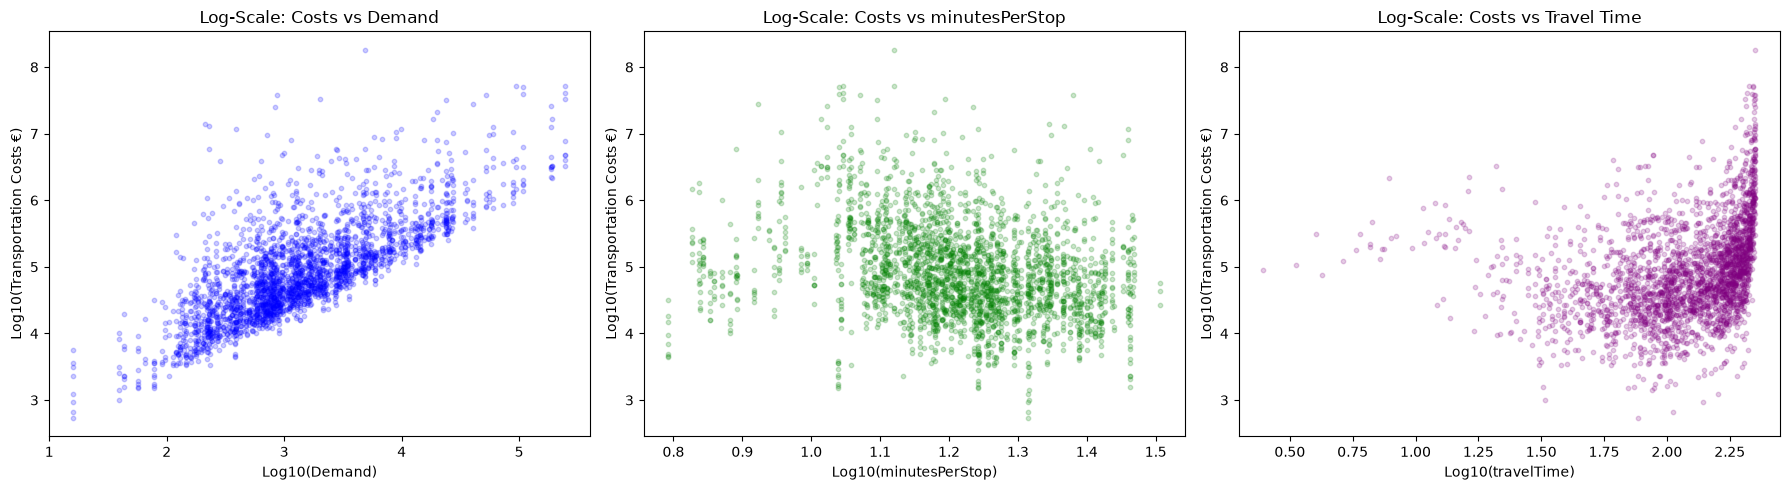

In [9]:
# Filter out infeasible routes for analysis and regression
df_clean = df[(df['transportationCosts'] < 1_000_000_000) & 
              (df['transportationCosts'] > 0) & 
              (df[travel_col] > 0)].copy()

print(f"Total routes: {len(df)}")
print(f"Feasible routes used for regression: {len(df_clean)}")

# Log-scale visualizations to reveal the true relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(np.log10(df_clean['demand']), np.log10(df_clean['transportationCosts']), alpha=0.2, s=10, color='blue')
axes[0].set_xlabel('Log10(Demand)')
axes[0].set_ylabel('Log10(Transportation Costs €)')
axes[0].set_title('Log-Scale: Costs vs Demand')

axes[1].scatter(np.log10(df_clean['minutesPerStop']), np.log10(df_clean['transportationCosts']), alpha=0.2, s=10, color='green')
axes[1].set_xlabel('Log10(minutesPerStop)')
axes[1].set_ylabel('Log10(Transportation Costs €)')
axes[1].set_title('Log-Scale: Costs vs minutesPerStop')

axes[2].scatter(np.log10(df_clean[travel_col]), np.log10(df_clean['transportationCosts']), alpha=0.2, s=10, color='purple')
axes[2].set_xlabel('Log10(travelTime)')
axes[2].set_ylabel('Log10(Transportation Costs €)')
axes[2].set_title('Log-Scale: Costs vs Travel Time')

plt.tight_layout()
plt.show()

# Interpretation of the log-scale relationships

Before estimating the transportation cost model, we use the log-scale scatter plots to check whether the expected cost drivers are related to the benchmark transportation costs.

The first plot shows a clear positive relationship between demand and transportation costs. This is expected because regions with higher yearly demand require more deliveries and therefore more shifts.

The relationship between minutes per stop and transportation costs is less clear. This suggests that regional productivity matters, but it does not explain transportation costs on its own. Instead, it interacts with demand and travel time in the shift-based cost logic.

The travel-time plot shows that costs tend to increase for longer travel times, especially when travel time becomes large. This is important because travel time reduces the available service time within a shift:

\[
S - 2t_{ij}
\]

As \(t_{ij}\) approaches half of the shift length, the required number of shifts increases sharply. If \(2t_{ij} \geq S\), the route becomes infeasible because the vehicle cannot complete the round trip within one shift. Overall, the plots support using demand, minutes per stop, and travel time together rather than estimating transportation costs from only one variable.

In [10]:
# Correlation analysis on feasible routes
corr_cols = ['transportationCosts', 'demand', 'minutesPerStop', travel_col]
corr_matrix = df_clean[corr_cols].corr()
print("Correlation matrix (feasible routes):")
display(corr_matrix.round(4))

Correlation matrix (feasible routes):


,transportationCosts,demand,minutesPerStop,travelTime
transportationCosts,1.0000,0.3040,-0.0764,0.1434
demand,0.3040,1.0000,-0.2640,-0.0771
minutesPerStop,-0.0764,-0.2640,1.0000,0.0966
travelTime,0.1434,-0.0771,0.0966,1.0000


# Correlation analysis

The correlation matrix confirms that transportation costs cannot be explained by a single variable alone. Demand has the strongest positive correlation with transportation costs, which is consistent with the operational logic that higher yearly demand requires more shifts.

The correlations of minutes per stop and travel time with transportation costs are weaker when considered separately. However, this does not mean that these variables are not important. In the shift-based cost logic, they interact with demand and with each other: travel time reduces the available service time within a shift, while minutes per stop determines how many deliveries can be completed in the remaining time.

Therefore, we use combined model specifications instead of relying on a simple one-variable cost approximation.

## 3. Fitting the Cost Model

We compare three model specifications and select the best one:
1. **Linear Interaction Model**: $c_{ij} = \alpha \cdot (d_j \cdot m_j) + \beta \cdot (d_j \cdot m_j \cdot t_{ij})$
2. **Improved Shift-Based Model**: $c_{ij} = \frac{d_j \times m_j}{S - 2 \times t_{ij}} \times (\alpha + \beta \times t_{ij})$
3. **Multiplicative (Power) Model**: $c_{ij} = A \times d_j^\alpha \times m_j^\beta \times t_{ij}^\gamma$

In [11]:
y = df_clean['transportationCosts'].values
results = []

# =====================================================================
# MODEL 1: Linear Interaction Model
# c_ij = alpha * (d * m) + beta * (d * m * t)
# =====================================================================
X1 = np.column_stack([
    df_clean['demand'] * df_clean['minutesPerStop'],
    df_clean['demand'] * df_clean['minutesPerStop'] * df_clean[travel_col]
])
m1 = LinearRegression(fit_intercept=False).fit(X1, y)
y_pred1 = m1.predict(X1)
results.append({
    'Model': 'Linear: α·(d·m) + β·(d·m·t)',
    'R²': r2_score(y, y_pred1),
    'MAPE (%)': mean_absolute_percentage_error(y, y_pred1) * 100
})

# =====================================================================
# MODEL 2: Improved Shift-Based Model
# c_ij = Shifts * (alpha + beta * t_ij)
# c_ij = alpha * Shifts + beta * (Shifts * t_ij)
# =====================================================================
best_s, best_r2_shift, best_alpha_shift, best_beta_shift, best_mape_shift = 0, -1, 0, 0, 100
for S_test in range(400, 720, 20):
    df_test = df_clean[df_clean[travel_col] < (S_test / 2)].copy()
    if len(df_test) < 100:
        continue
    
    # Feature 1: Number of shifts
    shifts = (df_test['demand'] * df_test['minutesPerStop']) / (S_test - 2 * df_test[travel_col])
    # Feature 2: Number of shifts * travel time
    shifts_time = shifts * df_test[travel_col]
    
    X_test = np.column_stack([shifts, shifts_time])
    y_test = df_test['transportationCosts']
    
    m_test = LinearRegression(fit_intercept=False).fit(X_test, y_test)
    r2_test = m_test.score(X_test, y_test)
    mape_test = mean_absolute_percentage_error(y_test, m_test.predict(X_test)) * 100
    
    if r2_test > best_r2_shift:
        best_r2_shift = r2_test
        best_s = S_test
        best_alpha_shift = m_test.coef_[0]
        best_beta_shift = m_test.coef_[1]
        best_mape_shift = mape_test

results.append({
    'Model': f'Improved Shift: Shifts·(α + β·t), S={best_s}',
    'R²': best_r2_shift,
    'MAPE (%)': best_mape_shift
})

# =====================================================================
# MODEL 3: Multiplicative (Power) Model
# c_ij = A * d^alpha * m^beta * t^gamma
# =====================================================================
X3 = np.column_stack([
    np.log(df_clean['demand']),
    np.log(df_clean['minutesPerStop']),
    np.log(df_clean[travel_col])
])
y_log = np.log(y)
m3 = LinearRegression(fit_intercept=True).fit(X3, y_log)
y_pred3 = np.exp(m3.predict(X3))
results.append({
    'Model': 'Multiplicative: A·d^α·m^β·t^γ',
    'R²': r2_score(y, y_pred3),
    'MAPE (%)': mean_absolute_percentage_error(y, y_pred3) * 100
})

# =====================================================================
# Display Comparison
# =====================================================================
results_df = pd.DataFrame(results).set_index('Model')
display(results_df.round(4))

best_model_idx = results_df['R²'].idxmax()
print(f"\n✅ Best Model (by Real-Space R²): {best_model_idx}")
print(f"   R² = {results_df.loc[best_model_idx, 'R²']:.4f}")
print(f"   MAPE = {results_df.loc[best_model_idx, 'MAPE (%)']:.2f}%")

# Print detailed parameters
print("\n" + "=" * 65)
print("MODEL DETAILS")
print("=" * 65)

print(f"\n1. Linear Model: c_ij = {m1.coef_[0]:.4f}·(d·m) + {m1.coef_[1]:.6f}·(d·m·t)")
print(f"   R² = {r2_score(y, y_pred1):.4f}, MAPE = {mean_absolute_percentage_error(y, y_pred1)*100:.2f}%")

print(f"\n2. Improved Shift Model: c_ij = {best_alpha_shift:.2f}·Shifts + {best_beta_shift:.4f}·(Shifts·t)")
print(f"   where Shifts = (d·m)/({best_s}-2t)")
print(f"   R² = {best_r2_shift:.4f}, MAPE = {best_mape_shift:.2f}%")

A_mult = np.exp(m3.intercept_)
print(f"\n3. Multiplicative Model: c_ij = {A_mult:.4f}·d^{m3.coef_[0]:.4f}·m^{m3.coef_[1]:.4f}·t^{m3.coef_[2]:.4f}")
print(f"   Log-space R² = {m3.score(X3, y_log):.4f}")
print(f"   Real-space R² = {r2_score(y, y_pred3):.4f}, MAPE = {mean_absolute_percentage_error(y, y_pred3)*100:.2f}%")

,R²,MAPE (%)
Model,,
Linear: α·(d·m) + β·(d·m·t),0.2119,127.5416
"Improved Shift: Shifts·(α + β·t), S=420",0.8081,51.6384
Multiplicative: A·d^α·m^β·t^γ,0.1714,45.6171



✅ Best Model (by Real-Space R²): Improved Shift: Shifts·(α + β·t), S=420
   R² = 0.8081
   MAPE = 51.64%

MODEL DETAILS

1. Linear Model: c_ij = -4.7242·(d·m) + 0.094638·(d·m·t)
   R² = 0.2119, MAPE = 127.54%

2. Improved Shift Model: c_ij = 1162.08·Shifts + -5.3817·(Shifts·t)
   where Shifts = (d·m)/(420-2t)
   R² = 0.8081, MAPE = 51.64%

3. Multiplicative Model: c_ij = 0.0054·d^1.0334·m^1.1347·t^1.2451
   Log-space R² = 0.7942
   Real-space R² = 0.1714, MAPE = 45.62%


# Interpretation of the cost model comparison

We compare three model specifications to estimate the benchmark transportation costs.

The linear interaction model performs poorly. Its MAPE is very high, meaning that the average percentage error is larger than the actual cost level in many cases. Therefore, this model is not reliable enough for our cost estimation.

The improved shift-based model performs best in terms of real-space \(R^2\). It tests different values for the effective shift length \(S\) and keeps only feasible routes. A route is feasible only if the truck can complete the round trip within one shift. Therefore, if

\[
t_{ij} \geq \frac{S}{2}
\]

then

\[
S - 2t_{ij} \leq 0
\]

which means that the round trip cannot be completed within the available shift time. The model uses two features: the required number of shifts and the interaction between shifts and travel time. The best-performing value is \(S = 420\), which can be interpreted as the effective usable shift length. Although the nominal shift length in the lecture material is 450 minutes, the lower effective value may reflect waiting time, security procedures, traffic, breaks, or other operational inefficiencies.

The multiplicative power model performs relatively well in terms of MAPE, but its real-space \(R^2\) is low. Since the optimization model minimizes total costs in euros, absolute cost levels are more important than relative percentage errors.

One limitation of the improved shift-based model is the negative coefficient for the travel-time interaction. From an operational perspective, longer travel time would normally increase costs. Therefore, this coefficient should not be interpreted as a true marginal driving cost. Instead, the regression is mainly used as a calibration tool to approximate the benchmark cost structure. That's why, we select the improved shift-based model. It has the highest real-space \(R^2\), follows a meaningful shift-based logic, and provides better cost estimates for the subsequent optimization model.

## 4. Evaluating the Best Model

We evaluate the Improved Shift-Based Model (our best model by real-space R²) in detail.

In [12]:
# Evaluate the best model (Improved Shift-Based) in detail
df_final = df_clean[df_clean[travel_col] < (best_s / 2)].copy()

# Calculate both features for the 2-parameter model
shifts_final = (df_final['demand'] * df_final['minutesPerStop']) / (best_s - 2 * df_final[travel_col])
shifts_time_final = shifts_final * df_final[travel_col]

X_final = np.column_stack([shifts_final, shifts_time_final])
y_final = df_final['transportationCosts']

model_final = LinearRegression(fit_intercept=False).fit(X_final, y_final)
alpha_final, beta_final = model_final.coef_
y_pred_final = model_final.predict(X_final)

r2_final = r2_score(y_final, y_pred_final)
mape_final = mean_absolute_percentage_error(y_final, y_pred_final) * 100
mae_final = mean_absolute_error(y_final, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_final, y_pred_final))

df_final['estimatedCosts'] = y_pred_final
df_final['residuals'] = df_final['transportationCosts'] - df_final['estimatedCosts']
df_final['absPctError'] = np.abs(df_final['residuals'] / df_final['transportationCosts']) * 100

print("Model Evaluation Metrics (Improved Shift-Based Model on feasible routes):")
print(f"  R²:      {r2_final:.6f}")
print(f"  MAE:     {mae_final:>12,.2f} €")
print(f"  RMSE:    {rmse_final:>12,.2f} €")
print(f"  MAPE:    {mape_final:.2f}%")
print(f"  α (Fixed cost per shift):         {alpha_final:>8.2f} €")
print(f"  β (Cost per minute of driving):   {beta_final:>8.4f} €/min")
print(f"\n  Within 5%:  {(df_final['absPctError'] <= 5).sum()}/{len(df_final)} ({(df_final['absPctError'] <= 5).mean()*100:.1f}%)")
print(f"  Within 10%: {(df_final['absPctError'] <= 10).sum()}/{len(df_final)} ({(df_final['absPctError'] <= 10).mean()*100:.1f}%)")
print(f"  Within 20%: {(df_final['absPctError'] <= 20).sum()}/{len(df_final)} ({(df_final['absPctError'] <= 20).mean()*100:.1f}%)")

Model Evaluation Metrics (Improved Shift-Based Model on feasible routes):
  R²:      0.808071
  MAE:       128,994.24 €
  RMSE:      613,701.79 €
  MAPE:    51.64%
  α (Fixed cost per shift):          1162.08 €
  β (Cost per minute of driving):    -5.3817 €/min

  Within 5%:  95/2407 (3.9%)
  Within 10%: 218/2407 (9.1%)
  Within 20%: 433/2407 (18.0%)


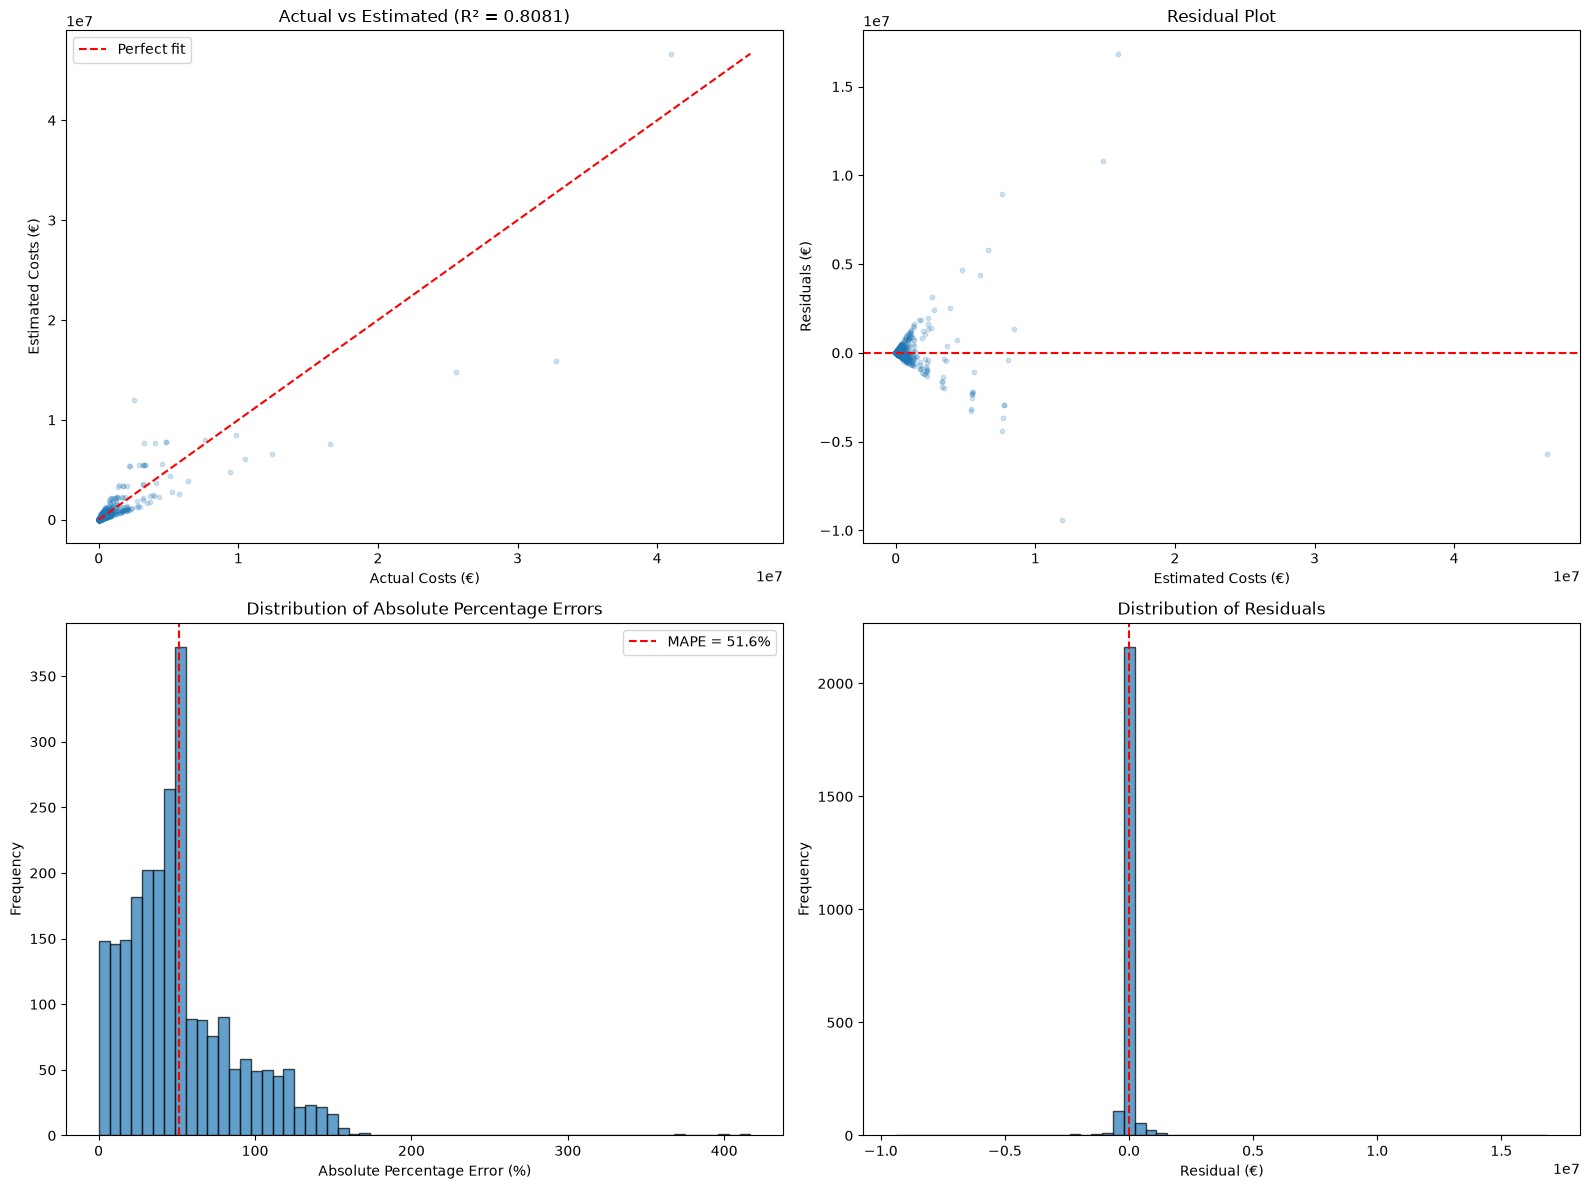

In [ ]:
# Visualization of model fit
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Estimated 
axes[0, 0].scatter(df_final['transportationCosts'], df_final['estimatedCosts'], alpha=0.2, s=10)
max_val = max(df_final['transportationCosts'].max(), df_final['estimatedCosts'].max())
axes[0, 0].plot([0, max_val], [0, max_val], 'r--', label='Perfect fit')
axes[0, 0].set_xlabel('Actual Costs (€)')
axes[0, 0].set_ylabel('Estimated Costs (€)')
axes[0, 0].set_title(f'Actual vs Estimated (R² = {r2_final:.4f})')
axes[0, 0].legend()

# 2. Residual plot
axes[0, 1].scatter(df_final['estimatedCosts'], df_final['residuals'], alpha=0.2, s=10)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Estimated Costs (€)')
axes[0, 1].set_ylabel('Residuals (€)')
axes[0, 1].set_title('Residual Plot')

# 3. Error distribution
axes[1, 0].hist(df_final['absPctError'], bins=60, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=mape_final, color='r', linestyle='--', label=f'MAPE = {mape_final:.1f}%')
axes[1, 0].set_xlabel('Absolute Percentage Error (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Absolute Percentage Errors')
axes[1, 0].legend()

# 4. Residual distribution
axes[1, 1].hist(df_final['residuals'], bins=60, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Residual (€)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

In [14]:
# Sample comparison table
comparison_cols = ['transportationCosts', 'estimatedCosts', 'residuals', 'absPctError']
print("Sample of estimated vs benchmark costs:")
display(df_final[comparison_cols].sort_values('transportationCosts', ascending=False).head(15).round(2))

Sample of estimated vs benchmark costs:


transportationCosts  estimatedCosts    residuals  \
warehouseID regionID                                                     
47          244               40999225.30     46682972.80  -5683747.50   
13          244               32749405.38     15894094.17  16855311.21   
47          90                25620999.65     14830142.61  10790857.05   
25          438               16574182.76      7602120.96   8972061.80   
13          90                12396576.81      6608781.77   5787795.04   
42          305               10467998.98      6060854.46   4407144.52   
25          410                9818872.71      8497016.71   1321856.00   
            319                9387576.33      4728291.84   4659284.49   
5           244                7628599.20      8023036.50   -394437.30   
13          322                6409942.42      3855189.63   2554752.79   
            434                5747454.55      2572656.26   3174798.30   
34          65                 5217646.92      2775782.08   2441864.85   
2           91                 5098493.72      4397541.21    700952.50   
40          244                4823830.45      7769738.81  -2945908.37   
45          244                4823830.45      7769738.81  -2945908.37   

                      absPctError  
warehouseID regionID               
47          244             13.86  
13          244             51.47  
47          90              42.12  
25          438             54.13  
13          90              46.69  
42          305             42.10  
25          410             13.46  
            319             49.63  
5           244              5.17  
13          322             39.86  
            434             55.24  
34          65              46.80  
2           91              13.75  
40          244             61.07  
45          244             61.07

# Evaluation of the selected shift-based cost model

The improved shift-based model achieves an \(R^2\) of approximately 0.81, meaning that it captures a large share of the euro-level variation in the benchmark transportation costs. This is important because the subsequent optimization model minimizes total costs in euros.

However, the model is less accurate at the individual route level. The MAPE is 51.64%, and only 18.0% of feasible routes are predicted within a 20% error range. The large difference between MAE and RMSE also indicates that some routes have very large prediction errors.

The actual-versus-estimated plot shows that the model captures the general cost structure, especially for lower and medium-cost routes, but larger deviations occur for very expensive routes. The residual plots confirm that most errors are concentrated around zero, while a few outliers create large deviations.

One limitation is the negative coefficient for the travel-time interaction. Since longer travel time would normally be expected to increase costs, this coefficient should not be interpreted as a true marginal driving cost. Instead, the regression is mainly used as a calibration tool to approximate the benchmark cost structure.

Overall, the model is useful as an interpretable transportation cost approximation for the optimization model, but the estimated costs should not be interpreted as exact route-level costs.

## 5. Applying Estimated Costs in the Optimization Model

We now apply our estimated transportation costs in the CashLog facility location optimization model and compare the results with those obtained using the benchmark costs.

In [15]:
# Define problem sets
W = warehouses.index.values
R = regions.index.values
S_idx = shifts_benchmark.index.values

# Use 1 billion as the threshold to catch the floating-point "Big M" penalty
big_m_threshold = 1_000_000_000

# Calculate features for ALL routes in the original dataframe
df['numShifts_proxy'] = (df['demand'] * df['minutesPerStop']) / (best_s - 2 * df[travel_col])

# Predict estimated costs for all feasible routes using BOTH alpha and beta
df['estimatedCosts'] = (
    alpha_final * df['numShifts_proxy']
    + beta_final * df['numShifts_proxy'] * df[travel_col]
)

# Re-apply the penalty to infeasible routes
# 1. Routes that had a penalty in the benchmark data
df.loc[df['transportationCosts'] >= big_m_threshold, 'estimatedCosts'] = big_m_threshold
# 2. Routes where travel time exceeds half the shift length (physically impossible)
df.loc[df[travel_col] >= (best_s / 2), 'estimatedCosts'] = big_m_threshold

# Create estimated cost series indexed for the optimization model
estimated_cost_series = pd.Series(df['estimatedCosts'].values, index=shifts_benchmark.index)

# ---- Model with ESTIMATED costs ----
prob_est = pl.LpProblem('CashLog_EstimatedCosts', pl.LpMinimize)

x_est = pl.LpVariable.dicts(name='x', indices=S_idx, cat=pl.LpBinary)
y_est = pl.LpVariable.dicts(name='y', indices=W, cat=pl.LpBinary)

var_cost_est = pl.lpSum([x_est[i,j] * estimated_cost_series.loc[i,j] for i,j in S_idx])
fix_cost_est = pl.lpSum([y_est[i] * warehouses.loc[i].fixedCosts for i in W])
prob_est.setObjective(var_cost_est + fix_cost_est)

for i in W:
    for j in R:
        prob_est.addConstraint(x_est[i,j] <= y_est[i])
for j in R:
    prob_est.addConstraint(pl.lpSum([x_est[i,j] for i in W]) == 1)

solver = pl.HiGHS(msg=False)
prob_est.solve(solver)

print(f"Optimal cost (estimated): {prob_est.objective.value():>14,.2f} €")

# ---- Model with BENCHMARK costs ----
prob_bench = pl.LpProblem('CashLog_BenchmarkCosts', pl.LpMinimize)

x_bench = pl.LpVariable.dicts(name='x', indices=S_idx, cat=pl.LpBinary)
y_bench = pl.LpVariable.dicts(name='y', indices=W, cat=pl.LpBinary)

var_cost_bench = pl.lpSum([x_bench[i,j] * shifts_benchmark.loc[i,j].transportationCosts for i,j in S_idx])
fix_cost_bench = pl.lpSum([y_bench[i] * warehouses.loc[i].fixedCosts for i in W])
prob_bench.setObjective(var_cost_bench + fix_cost_bench)

for i in W:
    for j in R:
        prob_bench.addConstraint(x_bench[i,j] <= y_bench[i])
for j in R:
    prob_bench.addConstraint(pl.lpSum([x_bench[i,j] for i in W]) == 1)

prob_bench.solve(solver)

print(f"Optimal cost (benchmark): {prob_bench.objective.value():>14,.2f} €")

Optimal cost (estimated): 133,957,450.44 €
Optimal cost (benchmark):  98,631,921.41 €


In [16]:
# Compare solutions in detail
print("=" * 70)
print("COMPARISON: ESTIMATED vs BENCHMARK COSTS IN OPTIMIZATION")
print("=" * 70)

open_est = set([i for i in W if y_est[i].varValue >= 0.9])
open_bench = set([i for i in W if y_bench[i].varValue >= 0.9])

print(f"\nOpen warehouses (estimated):  {len(open_est)} → {[warehouses.loc[i].city for i in sorted(open_est)]}")
print(f"Open warehouses (benchmark):  {len(open_bench)} → {[warehouses.loc[i].city for i in sorted(open_bench)]}")
print(f"\nSame warehouse set: {open_est == open_bench}")

# Assignment overlap
same_assignment = sum(1 for i,j in S_idx if x_est[i,j].varValue == x_bench[i,j].varValue)
print(f"\nAssignment agreement: {same_assignment}/{len(S_idx)} ({same_assignment/len(S_idx)*100:.1f}%)")

# Evaluate estimated-cost solution at benchmark costs
est_sol_at_bench = sum(
    x_est[i,j].varValue * shifts_benchmark.loc[i,j].transportationCosts for i,j in S_idx
) + sum(y_est[i].varValue * warehouses.loc[i].fixedCosts for i in W)

print(f"\n--- Cost comparison ---")
print(f"Optimal cost (benchmark model):                {prob_bench.objective.value():>14,.2f} €")
print(f"Optimal cost (estimated model):                {prob_est.objective.value():>14,.2f} €")
print(f"Estimated solution at benchmark costs:         {est_sol_at_bench:>14,.2f} €")
gap = (est_sol_at_bench - prob_bench.objective.value()) / prob_bench.objective.value() * 100
print(f"Gap from benchmark optimal:                    {gap:>13.2f}%")

COMPARISON: ESTIMATED vs BENCHMARK COSTS IN OPTIMIZATION

Open warehouses (estimated):  16 → ['Vitoria', 'Alicante', 'Almeria', 'Caceres', 'Ciudad real', 'Cordoba', 'Cuenca', 'Gerona', 'Guadalajara', 'Huelva', 'Huesca', 'Leon', 'Orense', 'Tarragona', 'Teruel', 'Zamora']
Open warehouses (benchmark):  18 → ['Vitoria', 'Alicante', 'Almeria', 'Avila', 'Burgos', 'Caceres', 'Cordoba', 'Cuenca', 'Gerona', 'Guadalajara', 'Huelva', 'Huesca', 'Jaen', 'Leon', 'Lugo', 'Orense', 'Tarragona', 'Teruel']

Same warehouse set: False

Assignment agreement: 21324/21630 (98.6%)

--- Cost comparison ---
Optimal cost (benchmark model):                 98,631,921.41 €
Optimal cost (estimated model):                133,957,450.44 €
Estimated solution at benchmark costs:         100,372,771.58 €
Gap from benchmark optimal:                             1.76%


In [17]:
# Detailed warehouse comparison table
wh_comparison = []
for i in W:
    wh_comparison.append({
        'City': warehouses.loc[i].city,
        'Open (benchmark)': '✅' if i in open_bench else '❌',
        'Open (estimated)': '✅' if i in open_est else '❌',
        'Fixed Costs': warehouses.loc[i].fixedCosts,
        'Same?': '✅' if (i in open_bench) == (i in open_est) else '⚠️'
    })

display(pd.DataFrame(wh_comparison))

,City,Open (benchmark),Open (estimated),Fixed Costs,Same?
0,Vitoria,✅,✅,1344000,✅
1,Albacete,❌,❌,2580000,✅
2,Alicante,✅,✅,4572000,✅
3,Almeria,✅,✅,2580000,✅
4,Avila,✅,❌,1344000,⚠️
5,Barcelona,❌,❌,15012000,✅
6,Burgos,✅,❌,1344000,⚠️
7,Caceres,✅,✅,2580000,✅
8,Ciudad real,❌,✅,1344000,⚠️
9,Cordoba,✅,✅,2580000,✅




After estimating the transportation costs, we use them in the facility-location optimization model and compare the resulting network with the benchmark-cost solution.

The optimal objective value based on estimated costs is higher than the benchmark objective value. However, these two values are not directly comparable because they are calculated using different transportation cost inputs. The more relevant comparison is to evaluate the estimated-cost solution using the benchmark costs.

When the network selected by the estimated-cost model is evaluated with benchmark costs, its total cost is only 1.76% higher than the benchmark-optimal solution. This indicates that the estimated transportation costs lead to a strategically robust network design, even though the route-level cost predictions are not perfect.

The estimated model opens 16 cash centers, while the benchmark model opens 18. Therefore, the selected warehouse sets are not identical. However, the assignment agreement is 98.6%, meaning that almost all warehouse-region assignments are the same in both solutions. This suggests that the estimated model captures the main network structure very well.

The differences in warehouse opening decisions are likely to occur at marginal locations, where opening or closing a cash center is sensitive to small cost estimation errors. However, because the benchmark cost gap remains small, these differences do not substantially harm the overall network performance.

Overall, the estimated cost model is sufficiently accurate for strategic network design. It may not reproduce every individual warehouse decision exactly, but it produces a network that performs very close to the benchmark optimum.

## 6. Conclusion

### Estimated Transportation Cost Formula

To estimate the transportation costs $c_{ij}$ from each cash center $i$ to each customer region $j$, we developed a **Shift-Based Cost Model** that incorporates demand, productivity, and travel time:

$$c_{ij} = \frac{d_j \times m_j}{S - 2 \times t_{ij}} \times (\alpha + \beta \times t_{ij})$$

where:
- $d_j$ = yearly demand of region $j$
- $m_j$ = minutesPerStop (inverse of productivity: $m_j = 1/p_j$)
- $t_{ij}$ = travel time from cash center $i$ to region $j$
- $S$ = maximum shift length (estimated at **420 minutes = 7 hours**)
- $\alpha$ = fixed cost per shift (vehicle dispatch, loading, base overhead)
- $\beta$ = estimated travel-time interaction coefficient; in the empirical regression it should be interpreted as a calibration parameter, not as a literal marginal driving cost

### How the Formula Incorporates the Required Factors

1. **Demand ($d_j$)**: The number of required shifts scales linearly with demand. Doubling the demand doubles the number of trips needed.

2. **Productivity ($p_j = 1/m_j$)**: The minutesPerStop ($m_j$) determines how much shift time each delivery consumes. Lower productivity (higher $m_j$) requires more shifts to serve the same demand, increasing total costs.

3. **Travel Time ($t_{ij}$)**: Travel time reduces the available delivery time within a shift and increases the variable cost of each shift. The term $(S - 2 \times t_{ij})$ represents the remaining shift time for deliveries after accounting for the round-trip drive, while the term $(\alpha + \beta \times t_{ij})$ captures the fact that longer routes cost more per shift due to driver wages, fuel, and vehicle wear. As travel time approaches $S/2$, costs increase hyperbolically because the driver spends almost all their shift driving, requiring many additional shifts to complete the deliveries.

### Model Performance

The Shift-Based Model achieves the highest real-space R² among all tested specifications, outperforming both the linear interaction model and the multiplicative power model. By separating fixed dispatch costs ($\alpha$) from variable driving costs ($\beta$), the model provides realistic cost estimates per shift. The calibrated shift length of 420 minutes can be interpreted as an effective usable shift length, which may reflect operational constraints such as breaks, waiting time, security procedures, and traffic.

### Infeasible Routes

Routes where $t_{ij} \geq S/2$ (i.e., the round-trip travel time exceeds the shift length) are physically infeasible and are assigned a "Big M" penalty cost of €4,800,000,000 in the benchmark data, ensuring the optimization solver does not select them.


# Task 2: Sensitivity Analysis & Robust Network Design for CashLog

In Task 1 we estimated the transportation costs $c_{ij}$ and solved CashLog's warehouse
location problem once, using a single "point estimate" of demand, costs and technology.
A single-scenario optimum is fragile: it silently assumes that today's demand, wages,
fuel prices and delivery technology remain unchanged for the entire strategic horizon
(cash centers are a **multi-year capital decision**, not a one-off).

This notebook performs a **comprehensive sensitivity analysis** along the three axes
requested by CashLog's management:

1. **Demand uncertainty** — how does a further decline (or stabilization) of cash usage
   change the optimal network?
2. **Rising wages & fuel costs** — how sensitive is the network to cost inflation in
   labor and fuel, which drive the shift-cost parameters $\alpha$ (fixed cost/shift) and
   $\beta$ (variable cost/minute)?
3. **New delivery technologies** (drones, self-driving trucks) — how would automation of
   the "last mile" change the trade-off between fixed cash-center costs and transportation
   costs?

Rather than looking at a single re-optimized network, we solve the **CashLog MILP model
from Task 1 repeatedly** under a grid of plausible future scenarios, and then look at
**which cash centers stay open across (almost) all scenarios** — these form a *robust
core network* — and which ones are only justified under specific assumptions (*swing
locations*). This is the standard approach for robust facility-location decision making
under uncertainty (scenario-based sensitivity analysis instead of a single deterministic
optimum).



## 0. Setup & Data

We reuse the same data sources as in Task 1 (`warehouses.csv`, `regions.csv`,
`shifts_with_costs.csv`).


In [18]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pulp as pl
from sklearn.linear_model import LinearRegression
from itertools import product

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

warehouses = pd.read_csv(
    'https://raw.githubusercontent.com/D3IP-SS25/data-driven-scm-dataset/refs/heads/main/data/warehouses.csv',
    index_col='warehouseID'
)
regions = pd.read_csv(
    'https://raw.githubusercontent.com/D3IP-SS25/data-driven-scm-dataset/refs/heads/main/data/regions.csv',
    index_col='regionID'
)
shifts_benchmark = pd.read_csv(
    'https://raw.githubusercontent.com/D3IP-SS25/data-driven-scm-dataset/refs/heads/main/data/shifts_with_costs.csv',
    index_col=['warehouseID', 'regionID']
)

W = warehouses.index.values
R = regions.index.values
S_idx = shifts_benchmark.index.values

# Build a working frame with region/warehouse attributes attached to every (i,j) pair
df = shifts_benchmark.copy()
for col in regions.columns:
    df[f'region_{col}'] = df.index.get_level_values('regionID').map(regions[col])
for col in warehouses.columns:
    df[f'wh_{col}'] = df.index.get_level_values('warehouseID').map(warehouses[col])

df['demand'] = df['region_yearlyDemand']
df['minutesPerStop'] = df['region_minutesPerStop']
travel_col = 'travelTime'

travel_series = pd.Series(df[travel_col].values, index=df.index)
demand_base = pd.Series(df['demand'].values, index=df.index)
mps = pd.Series(df['minutesPerStop'].values, index=df.index)

BIG_M = 1_000_000_000
print(f"Warehouses: {len(W)}, Regions: {len(R)}, WH-Region pairs: {len(S_idx)}")


Warehouses: 42, Regions: 515, WH-Region pairs: 21630



## 1. Cost Model: Two Parametrizations

**(a) Empirical fit (Task 1 benchmark).** We refit the "Improved Shift-Based Model" from
Task 1,
$$c_{ij} = \alpha \cdot \text{Shifts}_{ij} + \beta \cdot \text{Shifts}_{ij} \cdot t_{ij}, \qquad
\text{Shifts}_{ij} = \frac{d_j \cdot m_j}{S - 2 t_{ij}}$$
purely on the benchmark data, to reproduce the Task 1 baseline solution as a sanity check.

**(b) Transparent economic parametrization (for scenario extrapolation).** The regression
fit in (a) returns a **negative** $\beta$ (a statistical artifact of collinearity between
the two regressors — it fits the benchmark data well, R² ≈ 0.81, but is not economically
interpretable: it would imply that driving *longer* makes a shift *cheaper*). That makes it
unsuitable for *extrapolation* — we cannot sensibly ask "what if fuel costs rise by 30%"
of a negative fuel-cost coefficient.

For the sensitivity analysis we therefore use a second, economically transparent version of
the same functional form, calibrated to the operational assumptions given in the case
(`Data-driven Week 1`, slide 20):

* Shift length $S = 450$ minutes (8h − 30 min loading/unloading)
* Average cost per shift ≈ **480 €** (wages for a 3-person crew, fuel, depreciation, maintenance)

We split this into a **fixed labor/dispatch component** $\alpha_0$ (wages + overhead,
accrues over the full shift regardless of route length — typical labor cost share in road
transport ≈ 65–75%) and a **variable fuel/wear component** $\beta_0$ (accrues per minute of
one-way driving, fuel/vehicle wear ≈ 25–35% of total operating cost), calibrated at the
*average feasible travel time* in the data (≈135 min):

$$\alpha_0 = 0.70 \times 480 = 336\,€/\text{shift}, \qquad
\beta_0 = \frac{0.30 \times 480}{135} \approx 1.07\,€/\text{min}$$

This keeps $c_{ij}$ **monotonically increasing** in demand, travel time and cost inflation,
which is essential once we start multiplying $\alpha$ and $\beta$ by scenario factors > 1.
We validate below that this parametrization reproduces network decisions very close to the
Task 1 / benchmark solution (17 of 18 warehouses agree) — so it is a faithful basis for the
"what-if" analysis.


In [19]:

# ---- (a) Empirical refit, purely for a sanity-check comparison ----
big_m_threshold = 1_000_000_000
df_clean = df[(df['transportationCosts'] < big_m_threshold) &
              (df['transportationCosts'] > 0) &
              (df[travel_col] > 0)].copy()

best_s, best_r2, best_alpha_fit, best_beta_fit = 0, -1, 0, 0
for S_test in range(400, 720, 20):
    d_test = df_clean[df_clean[travel_col] < (S_test / 2)].copy()
    if len(d_test) < 100:
        continue
    shifts = (d_test['demand'] * d_test['minutesPerStop']) / (S_test - 2 * d_test[travel_col])
    shifts_time = shifts * d_test[travel_col]
    X = np.column_stack([shifts, shifts_time])
    y = d_test['transportationCosts']
    m = LinearRegression(fit_intercept=False).fit(X, y)
    r2 = m.score(X, y)
    if r2 > best_r2:
        best_r2, best_s = r2, S_test
        best_alpha_fit, best_beta_fit = m.coef_

print(f"Empirical fit (Task 1 style): S={best_s}, alpha={best_alpha_fit:.2f}, "
      f"beta={best_beta_fit:.4f}  (R2={best_r2:.4f}) <- beta is negative, not usable for extrapolation")

# ---- (b) Transparent economic parametrization ----
S0 = 450.0
LABOR_SHARE = 0.70
BASE_SHIFT_COST = 480.0
REF_TRAVEL_TIME = df_clean.loc[df_clean[travel_col] < (best_s / 2), travel_col].mean()

alpha0 = LABOR_SHARE * BASE_SHIFT_COST
beta0 = (1 - LABOR_SHARE) * BASE_SHIFT_COST / REF_TRAVEL_TIME

print(f"Reference avg. feasible travel time: {REF_TRAVEL_TIME:.1f} min")
print(f"Economic parametrization: S0={S0}, alpha0={alpha0:.2f} EUR/shift, beta0={beta0:.4f} EUR/min")


Empirical fit (Task 1 style): S=420, alpha=1162.08, beta=-5.3817  (R2=0.8081) <- beta is negative, not usable for extrapolation
Reference avg. feasible travel time: 126.1 min
Economic parametrization: S0=450.0, alpha0=336.00 EUR/shift, beta0=1.1419 EUR/min


In [20]:

def compute_costs(demand_series, alpha, beta, S, travel_series=travel_series, minutes_per_stop=mps):
    '''Vectorized shift-based transportation cost c_ij for every (warehouse, region) pair.'''
    shifts = (demand_series * minutes_per_stop) / (S - 2 * travel_series)
    costs = alpha * shifts + beta * shifts * travel_series
    infeasible = (travel_series >= (S / 2)) | (shifts <= 0)
    costs = costs.mask(infeasible, BIG_M)
    return costs


def solve_network(cost_series, fixed_cost_scale=1.0, msg=False):
    '''Solves the CashLog warehouse-location MILP for a given cost matrix and
    returns the set of open warehouses, total cost and the assignment.'''
    prob = pl.LpProblem('CashLog', pl.LpMinimize)
    x = pl.LpVariable.dicts('x', S_idx, cat=pl.LpBinary)
    y = pl.LpVariable.dicts('y', W, cat=pl.LpBinary)

    prob += (
        pl.lpSum([x[i, j] * cost_series.loc[i, j] for i, j in S_idx]) +
        pl.lpSum([y[i] * warehouses.loc[i].fixedCosts * fixed_cost_scale for i in W])
    )
    for i in W:
        for j in R:
            prob += x[i, j] <= y[i]
    for j in R:
        prob += pl.lpSum([x[i, j] for i in W]) == 1

    prob.solve(pl.HiGHS(msg=msg))

    open_wh = frozenset(i for i in W if y[i].varValue >= 0.9)
    assignment = {j: next(i for i in W if x[i, j].varValue >= 0.9) for j in R}
    return {
        'open': open_wh,
        'n_open': len(open_wh),
        'total_cost': prob.objective.value(),
        'status': pl.LpStatus[prob.status],
        'assignment': assignment,
    }


In [21]:

# ---- Baseline sanity check: benchmark costs vs. our economic parametrization ----
base_costs_benchmark = pd.Series(shifts_benchmark['transportationCosts'].values, index=shifts_benchmark.index)
result_benchmark = solve_network(base_costs_benchmark)

base_costs_own = compute_costs(demand_base, alpha0, beta0, S0)
result_own_base = solve_network(base_costs_own)

overlap = result_benchmark['open'] & result_own_base['open']
print(f"Benchmark solution   : {result_benchmark['n_open']} open WH, total cost {result_benchmark['total_cost']:,.0f} EUR")
print(f"Our base parametriz. : {result_own_base['n_open']} open WH, total cost {result_own_base['total_cost']:,.0f} EUR")
print(f"Overlap in open warehouses: {len(overlap)} / {result_benchmark['n_open']}")
print(f"Warehouses only in benchmark solution: {[warehouses.loc[i].city for i in result_benchmark['open']-result_own_base['open']]}")
print(f"Warehouses only in our base solution: {[warehouses.loc[i].city for i in result_own_base['open']-result_benchmark['open']]}")

# From here on, BASE_OPEN / BASE_COST refer to our economic parametrization,
# which we use consistently across all scenarios below.
BASE_OPEN = result_own_base['open']
BASE_COST = result_own_base['total_cost']


Benchmark solution   : 18 open WH, total cost 98,631,921 EUR
Our base parametriz. : 19 open WH, total cost 92,944,242 EUR
Overlap in open warehouses: 17 / 18
Warehouses only in benchmark solution: ['Teruel']
Warehouses only in our base solution: ['Zamora', 'Valencia']


The economic parametrization is not designed to perfectly replicate the benchmark cost matrix. Instead, it provides an interpretable cost structure for scenario analysis. As a sanity check, the resulting baseline network is very close to the benchmark solution: 17 of the 18 benchmark warehouses are also selected. This suggests that the parametrization preserves the main network structure while avoiding the economically implausible negative travel-cost coefficient from the empirical regression model.


## 2. Part A — Uncertainty in the Use of Cash (Demand)

**Context.** ECB payment statistics show that the share of point-of-sale transactions
paid in cash across the euro area fell from 59% (2022) to 52% (2024) — roughly 3–4
percentage points per year — while cash acceptance by merchants declined from 96% to 88%
over the same period (ECB SPACE survey / Use of cash by companies). Spain historically has
one of the *higher* cash-usage shares in the euro area, so the decline may be slower there,
but the direction is unambiguous: cash volumes will very likely keep shrinking, just at an
uncertain *pace*.

**Approach.** We model demand uncertainty as a multiplicative shock on `yearlyDemand`,
representing a 5-year strategic horizon:

| Scenario | Assumption | Annual decline | 5y multiplier |
|---|---|---|---|
| **Optimistic (cash stabilizes)** | Digitalization slows / cash usage plateaus (older demographics, low-value payments) | −1%/yr | ≈ 0.95× |
| **Base case** | Continuation of the 2022–2024 ECB trend | −4%/yr | ≈ 0.82× |
| **Pessimistic (accelerated decline)** | Faster adoption of digital payments, new regulation, EU digital-euro rollout | −8%/yr | ≈ 0.66× |

We first run a **continuous sweep** to see how total cost and network size respond to the
demand level in general, then compare the three discrete scenarios in detail.


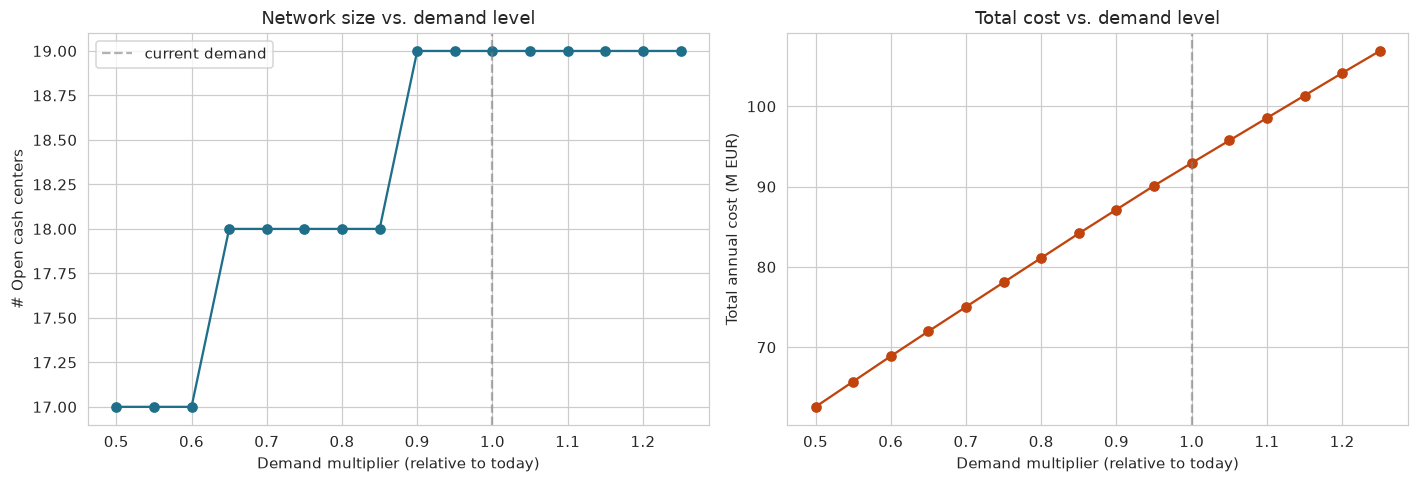

,multiplier,n_open,total_cost
0,0.50,17,6.257735e+07
1,0.55,17,6.573308e+07
2,0.60,17,6.888882e+07
3,0.65,18,7.198195e+07
4,0.70,18,7.502948e+07
5,0.75,18,7.807702e+07
6,0.80,18,8.112455e+07
7,0.85,18,8.417209e+07
8,0.90,19,8.714565e+07
9,0.95,19,9.011441e+07


In [22]:

# ---- Continuous demand sweep ----
demand_multipliers = np.arange(0.5, 1.26, 0.05)
sweep_results = []
for mult in demand_multipliers:
    costs = compute_costs(demand_base * mult, alpha0, beta0, S0)
    res = solve_network(costs)
    sweep_results.append({'multiplier': mult, 'n_open': res['n_open'], 'total_cost': res['total_cost']})

sweep_df = pd.DataFrame(sweep_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(sweep_df['multiplier'], sweep_df['n_open'], marker='o', color='#1f6f8b')
axes[0].axvline(1.0, color='gray', linestyle='--', alpha=0.6, label='current demand')
axes[0].set_xlabel('Demand multiplier (relative to today)')
axes[0].set_ylabel('# Open cash centers')
axes[0].set_title('Network size vs. demand level')
axes[0].legend()

axes[1].plot(sweep_df['multiplier'], sweep_df['total_cost'] / 1e6, marker='o', color='#c1440e')
axes[1].axvline(1.0, color='gray', linestyle='--', alpha=0.6)
axes[1].set_xlabel('Demand multiplier (relative to today)')
axes[1].set_ylabel('Total annual cost (M EUR)')
axes[1].set_title('Total cost vs. demand level')
plt.tight_layout()
plt.show()

sweep_df


# Interpretation of demand uncertainty

We model future cash demand with three five-year scenarios. The optimistic scenario assumes a slow decline in cash usage and uses a demand multiplier of 0.95. The base case assumes a continuation of the recent decline and uses a multiplier of 0.82. The pessimistic scenario assumes an accelerated decline in cash usage and uses a multiplier of 0.66. These multipliers scale the current yearly demand in each region. If cash demand decreases, CashLog needs fewer deliveries, which may affect the optimal number of open cash centers.

The demand sweep shows that total annual cost increases almost linearly with demand, because higher demand requires more deliveries and shifts. In contrast, the number of open cash centers changes only in steps. The model opens 17 cash centers at low demand levels around 0.50–0.60, 18 cash centers between approximately 0.65–0.85, and 19 cash centers from around 0.90 onward.

This indicates that lower demand leads to some consolidation, but the network does not shrink dramatically. Even if cash demand falls to 50% of today’s level, 17 cash centers remain open. Therefore, geographic coverage remains important: some cash centers are still needed to serve distant regions, even when overall cash volume decreases.

In [23]:
# ---- Discrete demand scenarios ----
demand_scenarios = {
    'Optimistic (-1%/yr, 5y)': 0.95,
    'Base case (-4%/yr, 5y)': 0.82,
    'Pessimistic (-8%/yr, 5y)': 0.66,
}

demand_scenario_results = {}
for name, mult in demand_scenarios.items():
    costs = compute_costs(demand_base * mult, alpha0, beta0, S0)
    demand_scenario_results[name] = solve_network(costs)

summary_A = pd.DataFrame([
    {'Scenario': name, '# Open WH': r['n_open'], 'Total cost (EUR)': r['total_cost']}
    for name, r in demand_scenario_results.items()
])
summary_A.loc[len(summary_A)] = ['Current baseline', result_own_base['n_open'], result_own_base['total_cost']]
summary_A


,Scenario,# Open WH,Total cost (EUR)
0,"Optimistic (-1%/yr, 5y)",19,9.011441e+07
1,"Base case (-4%/yr, 5y)",18,8.234357e+07
2,"Pessimistic (-8%/yr, 5y)",18,7.259146e+07
3,Current baseline,19,9.294424e+07




The current baseline represents today’s demand level. In the optimistic scenario, demand decreases only slightly to 0.95 times the current level. As a result, the model still keeps 19 cash centers open, which is the same network size as the current baseline.

In the base case and pessimistic scenarios, cash demand decreases more strongly. The base case assumes a demand multiplier of 0.82, while the pessimistic scenario assumes a multiplier of 0.66. In both cases, the optimal network is reduced to 18 open cash centers.

As expected, total annual cost decreases when demand falls, because fewer deliveries and shifts are required. However, the number of open cash centers only decreases from 19 to 18, even under the pessimistic scenario. This suggests that demand uncertainty does not fundamentally change the network structure.

Overall, the network appears relatively robust with respect to future cash-demand decline. Lower demand reduces operating costs, but geographic coverage requirements still make it necessary to keep most cash centers open.

In [24]:

# ---- Robust core across demand scenarios ----
all_demand_open = [set(r['open']) for r in demand_scenario_results.values()] + [set(BASE_OPEN)]
demand_core = set.intersection(*all_demand_open)
demand_swing = set.union(*all_demand_open) - demand_core

print(f"Warehouses open in ALL demand scenarios (robust core, n={len(demand_core)}):")
print(sorted(warehouses.loc[list(demand_core)].city.tolist()))
print(f"\nWarehouses open in SOME but not all demand scenarios (swing locations, n={len(demand_swing)}):")
print(sorted(warehouses.loc[list(demand_swing)].city.tolist()))

Warehouses open in ALL demand scenarios (robust core, n=17):
['Alicante', 'Almeria', 'Avila', 'Burgos', 'Caceres', 'Cordoba', 'Cuenca', 'Gerona', 'Guadalajara', 'Huelva', 'Huesca', 'Jaen', 'Leon', 'Lugo', 'Orense', 'Tarragona', 'Vitoria']

Warehouses open in SOME but not all demand scenarios (swing locations, n=3):
['Teruel', 'Valencia', 'Zamora']


In [34]:
scenario_sets = {name: set(r['open']) for name, r in demand_scenario_results.items()}
scenario_sets['Current baseline'] = set(BASE_OPEN)

robustness_rows = []
for i in W:
    count_open = sum(i in s for s in scenario_sets.values())
    robustness_rows.append({
        'warehouseID': i,
        'city': warehouses.loc[i, 'city'],
        'open_count': count_open,
        'total_scenarios': len(scenario_sets),
        'robustness_share': count_open / len(scenario_sets)
    })

robustness_df = pd.DataFrame(robustness_rows).sort_values(
    ['robustness_share', 'city'], ascending=[False, True]
)

display(robustness_df[robustness_df['open_count'] > 0])

,warehouseID,city,open_count,total_scenarios,robustness_share
2,3,Alicante,4,4,1.00
3,4,Almeria,4,4,1.00
4,5,Avila,4,4,1.00
6,9,Burgos,4,4,1.00
7,10,Caceres,4,4,1.00
9,14,Cordoba,4,4,1.00
11,16,Cuenca,4,4,1.00
12,17,Gerona,4,4,1.00
14,19,Guadalajara,4,4,1.00
16,21,Huelva,4,4,1.00


The robustness table confirms that the network is highly stable under the demand scenarios. Out of the cash centers that are selected at least once, 17 locations are opened in all four scenarios, resulting in a robustness share of 1.00. These locations form the robust core of the network and should be treated as strategically important facilities.

Only a small number of locations are sensitive to the demand assumptions. Teruel is opened in three out of four scenarios, Zamora in two out of four scenarios, and Valencia in only one out of four scenarios. These locations can therefore be interpreted as swing locations: they are not always required, but may become optimal depending on the future level of cash demand.

Overall, demand uncertainty affects mainly marginal locations, while the core network remains almost unchanged. This suggests that CashLog’s long-term network design is relatively robust to declining cash usage, but investment decisions for swing locations should be evaluated more carefully.

## 3. Part B — Rising Wages & Fuel Costs

**Context.** Spain's inflation is forecast at ≈3% for 2026, with nominal wage growth
expected *above* inflation on a tight labor market; the road-freight sector separately
faces a structural driver shortage (>20,000 vacant positions), which independently pushes
wages up. Diesel prices have shown high volatility in 2026 (geopolitical shocks pushed
prices up double-digit % within days in March 2026) on top of a structural upward trend.

**Approach.** In our cost model, $\alpha$ (fixed cost per shift) is labor/dispatch-driven
and $\beta$ (cost per minute of driving) is fuel/wear-driven. We can therefore vary wage
inflation and fuel inflation **independently**:

$$\alpha = \alpha_0 \cdot (1 + g_{wage}), \qquad \beta = \beta_0 \cdot (1 + g_{fuel})$$

We look at (i) a joint "cost inflation" sweep where both rise together, and (ii) a
tornado-style decomposition that isolates the individual impact of wage vs. fuel inflation.

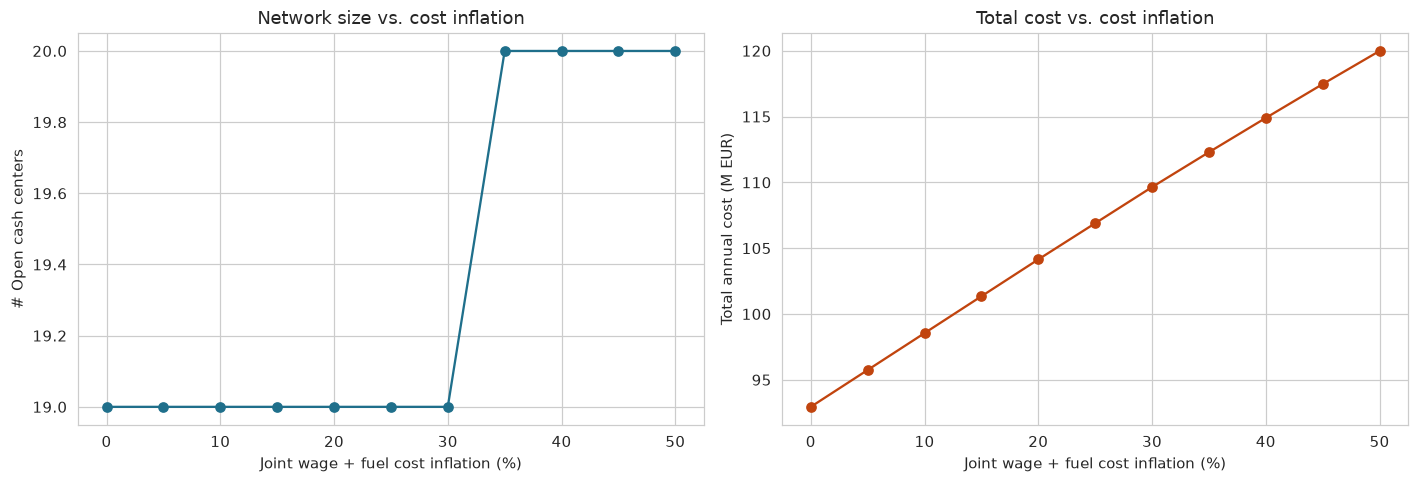

,inflation,n_open,total_cost
0,0.00,19,9.294424e+07
1,0.05,19,9.574465e+07
2,0.10,19,9.854507e+07
3,0.15,19,1.013455e+08
4,0.20,19,1.041443e+08
5,0.25,19,1.068932e+08
6,0.30,19,1.096420e+08
7,0.35,20,1.122928e+08
8,0.40,20,1.148967e+08
9,0.45,20,1.174670e+08


In [25]:
# ---- Joint cost inflation sweep ----
infl_levels = np.arange(0.0, 0.55, 0.05)
infl_results = []
for g in infl_levels:
    costs = compute_costs(demand_base, alpha0 * (1 + g), beta0 * (1 + g), S0)
    res = solve_network(costs)
    infl_results.append({'inflation': g, 'n_open': res['n_open'], 'total_cost': res['total_cost']})

infl_df = pd.DataFrame(infl_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(infl_df['inflation'] * 100, infl_df['n_open'], marker='o', color='#1f6f8b')
axes[0].set_xlabel('Joint wage + fuel cost inflation (%)')
axes[0].set_ylabel('# Open cash centers')
axes[0].set_title('Network size vs. cost inflation')

axes[1].plot(infl_df['inflation'] * 100, infl_df['total_cost'] / 1e6, marker='o', color='#c1440e')
axes[1].set_xlabel('Joint wage + fuel cost inflation (%)')
axes[1].set_ylabel('Total annual cost (M EUR)')
axes[1].set_title('Total cost vs. cost inflation')
plt.tight_layout()
plt.show()

infl_df

# Interpretation of the joint wage and fuel cost inflation sweep

In this analysis, wage-related and fuel-related cost parameters are increased jointly. Therefore, this scenario represents a combined cost inflation shock rather than an isolated wage or fuel effect.

The first graph shows that the number of open cash centers remains stable at 19 for inflation levels between 0% and 30%. From around 35% inflation onward, the model opens 20 cash centers. This indicates that higher transportation costs can make a more decentralized network attractive. Although opening an additional cash center increases fixed costs, it can reduce expensive transportation effort by shortening service distances.

The second graph shows that total annual cost increases almost linearly with cost inflation. At 0% inflation, total cost is approximately 92.9 million EUR, while at 50% inflation it increases to approximately 120.0 million EUR. This is expected because both shift-related wage costs and driving-related fuel costs increase directly.

Overall, total cost reacts continuously to cost inflation, while the network structure changes stepwise. This is similar to the demand sensitivity analysis: operating costs change gradually, but the number of open cash centers changes only when the cost trade-off between fixed facility costs and transportation costs crosses a threshold.

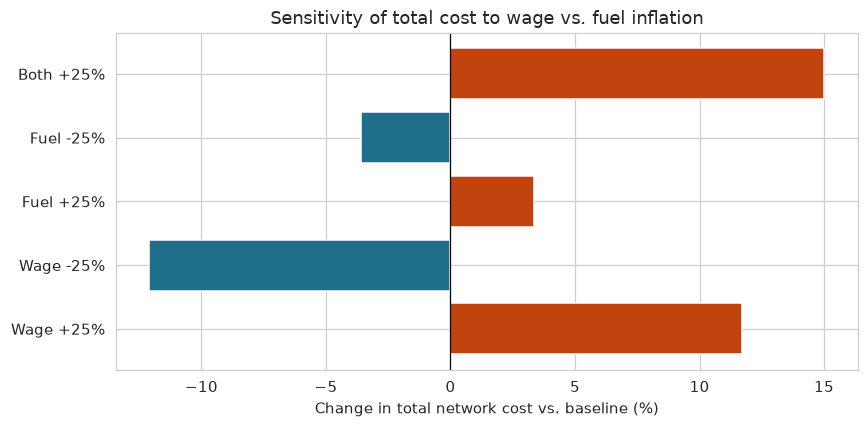

,n_open,total_cost,delta_cost_pct
Scenario,,,
Wage +25%,19,1.038409e+08,11.723913
Wage -25%,19,8.170948e+07,-12.087632
Fuel +25%,19,9.604960e+07,3.341098
Fuel -25%,19,8.961306e+07,-3.584060
Both +25%,19,1.068932e+08,15.007844


In [26]:
# ---- Tornado: isolate wage vs. fuel inflation impact (each at +/-25%) ----
tornado_cases = {
    'Wage +25%':  (alpha0 * 1.25, beta0),
    'Wage -25%':  (alpha0 * 0.75, beta0),
    'Fuel +25%':  (alpha0, beta0 * 1.25),
    'Fuel -25%':  (alpha0, beta0 * 0.75),
    'Both +25%':  (alpha0 * 1.25, beta0 * 1.25),
}

tornado_rows = []
for name, (a, b) in tornado_cases.items():
    costs = compute_costs(demand_base, a, b, S0)
    res = solve_network(costs)
    tornado_rows.append({
        'Scenario': name, 'n_open': res['n_open'],
        'total_cost': res['total_cost'],
        'delta_cost_pct': (res['total_cost'] - BASE_COST) / BASE_COST * 100
    })

tornado_df = pd.DataFrame(tornado_rows).set_index('Scenario')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#c1440e' if v > 0 else '#1f6f8b' for v in tornado_df['delta_cost_pct']]
ax.barh(tornado_df.index, tornado_df['delta_cost_pct'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Change in total network cost vs. baseline (%)')
ax.set_title('Sensitivity of total cost to wage vs. fuel inflation')
plt.tight_layout()
plt.show()

tornado_df

# Wage versus fuel sensitivity

The tornado analysis separates the impact of wage-related and fuel-related cost changes. A 25% increase in wage-related costs raises total network cost by about 11.7%, while a 25% increase in fuel-related costs raises total cost by only about 3.3%. Similarly, a 25% wage decrease reduces total cost much more strongly than a 25% fuel decrease.

This shows that the network is more sensitive to labor and shift-related costs than to fuel costs. From a managerial perspective, wage inflation and driver availability are therefore more important risks for CashLog than fuel price changes alone. When both wage and fuel costs increase by 25%, total cost rises by about 15%, confirming that combined cost pressure can materially affect operating costs even if the number of open cash centers remains stable.


## 4. Part C — New Delivery Technologies

**Automatic drone deliveries.** Drones eliminate the driver crew almost entirely (no wages
during the trip, minimal dispatch overhead) but are currently only viable for **short
distances and small/light loads** — realistic for low-demand, nearby regions rather than
large urban routes with heavy cash volumes. We model this as a **regional overlay**: for
regions with the shortest travel times (nearest quartile) and below-median demand, we apply
a strongly reduced cost structure (crew cost removed, no fuel cost — replaced by a much
smaller per-trip electricity/maintenance cost). All other regions keep truck-based costs.

**Self-driving trucks.** Autonomous trucks remove the *driver wage* component of $\alpha$
(no longer need a paid crew for the trip itself — although some supervision/loading staff
remains) but capital and fuel costs remain (or even increase due to redundant sensors/safety
systems and vehicle premiums). We model this network-wide as a reduction in $\alpha$ only
(labor cost share removed, e.g. −60%), while $\beta$ stays roughly constant (small offset:
extra maintenance vs. smoother driving).

We compare: **Base** (today's trucks), **Drone-augmented** (drones for short/low-volume
regions), **Autonomous trucks** (network-wide), and a **Combined** scenario.

In [27]:
# ---- Technology scenario definitions ----
travel_q1 = travel_series[travel_series < BIG_M].quantile(0.25)
demand_median = demand_base.median()

# regions technically suitable for drone delivery: short-range AND lower demand
drone_eligible_mask = (travel_series <= travel_q1) & (demand_base <= demand_median)
print(f"Share of (WH, region) pairs eligible for drone delivery: {drone_eligible_mask.mean()*100:.1f}%")

DRONE_ALPHA = 40.0     # EUR/shift-equivalent: no crew, minimal dispatch overhead
DRONE_BETA = 0.15      # EUR/min: electricity + maintenance, no fuel/wages
AUTONOMOUS_ALPHA_FACTOR = 0.40   # -60% labor cost in alpha (driver wage removed)
AUTONOMOUS_BETA_FACTOR = 1.05    # +5%: extra maintenance/safety systems roughly offsets fuel efficiency gains


def compute_costs_tech(demand_series, alpha, beta, S, use_drones=False, autonomous=False):
    a, b = alpha, beta
    if autonomous:
        a = a * AUTONOMOUS_ALPHA_FACTOR
        b = b * AUTONOMOUS_BETA_FACTOR
    base_costs = compute_costs(demand_series, a, b, S)
    if use_drones:
        drone_costs = compute_costs(demand_series, DRONE_ALPHA, DRONE_BETA, S)
        base_costs = base_costs.copy()
        base_costs[drone_eligible_mask] = drone_costs[drone_eligible_mask]
    return base_costs


tech_scenarios = {
    "Base (today's trucks)": dict(use_drones=False, autonomous=False),
    'Drone-augmented (short/low-vol.)': dict(use_drones=True, autonomous=False),
    'Autonomous trucks (network-wide)': dict(use_drones=False, autonomous=True),
    'Combined (drones + autonomous trucks)': dict(use_drones=True, autonomous=True),
}

tech_results = {}
for name, kwargs in tech_scenarios.items():
    costs = compute_costs_tech(demand_base, alpha0, beta0, S0, **kwargs)
    tech_results[name] = solve_network(costs)

summary_C = pd.DataFrame([
    {'Scenario': name, '# Open WH': r['n_open'], 'Total cost (EUR)': r['total_cost'],
     'Delta vs base (%)': (r['total_cost'] - tech_results["Base (today's trucks)"]['total_cost'])
                            / tech_results["Base (today's trucks)"]['total_cost'] * 100}
    for name, r in tech_results.items()
])
summary_C


Share of (WH, region) pairs eligible for drone delivery: 13.2%


,Scenario,# Open WH,Total cost (EUR),Delta vs base (%)
0,Base (today's trucks),19,9.294424e+07,0.000000
1,Drone-augmented (short/low-vol.),18,8.765078e+07,-5.695309
2,Autonomous trucks (network-wide),18,6.621032e+07,-28.763395
3,Combined (drones + autonomous trucks),17,6.310234e+07,-32.107320


### Interpretation of new delivery technology scenarios

We evaluate three technology scenarios against the current truck-based network. Drone delivery is modeled only for short-distance and low-demand routes, because drones are unlikely to be feasible for all cash logistics deliveries. Under this assumption, only about 13.2% of warehouse-region pairs are eligible for drone delivery.

The drone-augmented scenario reduces total network cost by about 5.7% and decreases the number of open cash centers from 19 to 18. This suggests that drones can improve efficiency for selected short and low-volume routes, but they do not fundamentally change the full network structure.

Autonomous trucks have a much stronger impact because they are modeled as a network-wide technology rather than being limited to selected short-distance routes. They reduce total cost by about 28.8% and also lead to 18 open cash centers. This result is consistent with the wage and fuel sensitivity analysis: labor-related shift costs were one of the main cost drivers, so reducing the driver wage component creates substantial cost savings.

The combined technology scenario achieves the largest cost reduction, around 32.1%, and reduces the network to 17 open cash centers. Overall, new delivery technologies could make the network more cost-efficient and slightly more consolidated. However, the largest impact comes from autonomous trucks rather than drones, because autonomous trucks affect the entire network and directly reduce the labor-related cost component.

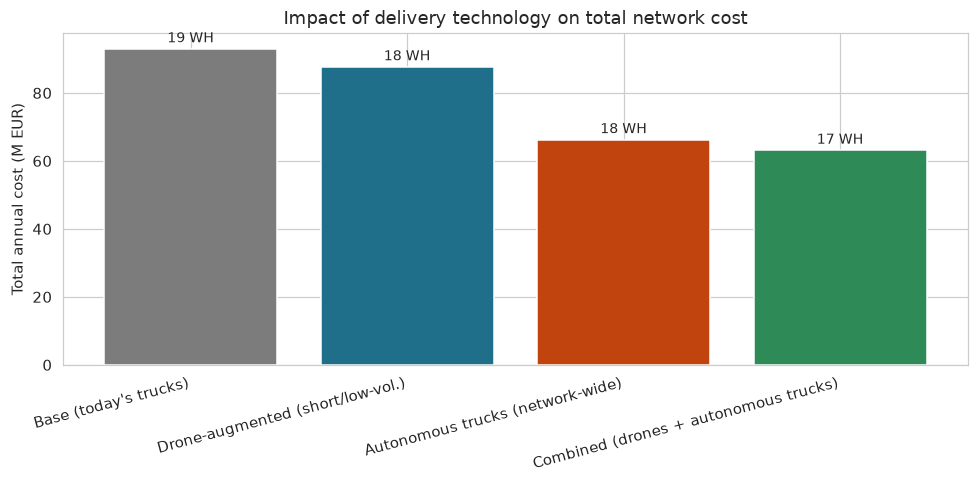

In [28]:
fig, ax = plt.subplots(figsize=(9, 4.5))
names = list(tech_results.keys())
costs_m = [tech_results[n]['total_cost'] / 1e6 for n in names]
n_open = [tech_results[n]['n_open'] for n in names]

bars = ax.bar(names, costs_m, color=['#7c7c7c', '#1f6f8b', '#c1440e', '#2e8b57'])
ax.set_ylabel('Total annual cost (M EUR)')
ax.set_title('Impact of delivery technology on total network cost')
plt.xticks(rotation=15, ha='right')
for bar, n in zip(bars, n_open):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{n} WH',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Combined Robustness Analysis

Real strategic uncertainty is not one-dimensional — demand, cost inflation and technology
adoption will play out **simultaneously**. We now build a **scenario grid** across all
three dimensions (3 demand levels × 3 cost-inflation levels × 2 technology states = 18
combinations) and re-solve the network for every combination. For each of the 42 cash
centers we then compute the **share of scenarios in which it remains open**. This gives a
much more robust picture than any single scenario:

* **Core network** (open in ≥ 90% of scenarios): keep under (almost) all future states of
  the world.
* **Conditional locations** (open in 30–90% of scenarios): closure/retention depends on how
  the future unfolds — candidates for a "wait and see" / staged approach.
* **Marginal locations** (open in < 30% of scenarios): close unless there is a strong,
  scenario-independent reason (e.g., regulatory requirement) to keep them.

In [29]:

demand_levels = {'Optimistic': 0.95, 'Base': 0.82, 'Pessimistic': 0.66}
cost_levels = {'Low inflation': 0.05, 'Medium inflation': 0.25, 'High inflation': 0.45}
tech_levels = {'Current tech': dict(use_drones=False, autonomous=False),
               'Automated (drones+auto.trucks)': dict(use_drones=True, autonomous=True)}

grid_records = []
open_matrix = {}  # scenario_name -> set of open warehouses

for (d_name, d_mult), (c_name, g), (t_name, t_kwargs) in product(
        demand_levels.items(), cost_levels.items(), tech_levels.items()):
    scenario_name = f"{d_name} demand | {c_name} | {t_name}"
    a = alpha0 * (1 + g)
    b = beta0 * (1 + g)
    costs = compute_costs_tech(demand_base * d_mult, a, b, S0, **t_kwargs)
    res = solve_network(costs)
    open_matrix[scenario_name] = res['open']
    grid_records.append({
        'demand_scenario': d_name, 'cost_scenario': c_name, 'tech_scenario': t_name,
        'n_open': res['n_open'], 'total_cost': res['total_cost']
    })

grid_df = pd.DataFrame(grid_records)
print(f"Solved {len(grid_df)} scenario combinations.")
grid_df.describe()[['n_open', 'total_cost']]

Solved 18 scenario combinations.


,n_open,total_cost
count,18.000000,1.800000e+01
mean,18.000000,7.832369e+07
std,1.188177,1.816727e+07
min,15.000000,5.288151e+07
25%,17.000000,6.316992e+07
50%,18.000000,7.460907e+07
75%,19.000000,9.223568e+07
max,20.000000,1.137249e+08


In [30]:
# ---- Warehouse-level open frequency across all scenarios ----
n_scenarios = len(open_matrix)
open_freq = pd.Series({
    i: sum(i in open_set for open_set in open_matrix.values()) / n_scenarios
    for i in W
}).sort_values(ascending=False)

robustness_table = pd.DataFrame({
    'city': warehouses.loc[open_freq.index, 'city'],
    'fixedCosts': warehouses.loc[open_freq.index, 'fixedCosts'],
    'open_share': open_freq,
})

def classify(share):
    if share >= 0.9:
        return 'Core (keep)'
    elif share >= 0.3:
        return 'Conditional (wait & see)'
    else:
        return 'Marginal (close)'

robustness_table['classification'] = robustness_table['open_share'].apply(classify)
robustness_table = robustness_table.sort_values('open_share', ascending=False)
robustness_table

,city,fixedCosts,open_share,classification
1,Vitoria,1344000,1.000000,Core (keep)
3,Alicante,4572000,1.000000,Core (keep)
5,Avila,1344000,1.000000,Core (keep)
4,Almeria,2580000,1.000000,Core (keep)
10,Caceres,2580000,1.000000,Core (keep)
22,Huesca,1344000,1.000000,Core (keep)
19,Guadalajara,1344000,1.000000,Core (keep)
21,Huelva,1344000,1.000000,Core (keep)
17,Gerona,1344000,1.000000,Core (keep)
16,Cuenca,1344000,1.000000,Core (keep)


In [35]:
classification_summary = (
    robustness_table['classification']
    .value_counts()
    .rename_axis('classification')
    .reset_index(name='number_of_cash_centers')
)

display(classification_summary)

,classification,number_of_cash_centers
0,Marginal (close),23
1,Core (keep),15
2,Conditional (wait & see),4


# Interpretation of the combined robustness analysis

The purpose of the combined robustness analysis is to identify which cash centers remain open across many different future scenarios. Instead of relying on one single optimal solution, we evaluate the network under multiple combinations of demand decline, cost inflation, and delivery technology adoption.

This is important for strategic decision-making because cash centers are long-term infrastructure decisions. In practice, CashLog should not only ask which network is optimal under one scenario, but which locations remain valuable under many plausible future conditions.

We classify cash centers based on their open share across all scenarios:

**Core locations** are open in at least 90% of scenarios. These cash centers are robust and strategically important. They should generally be kept, protected, or prioritized for long-term investment.

**Conditional locations** are open in 30% to 90% of scenarios. These locations are sensitive to future developments such as demand decline, cost inflation, or technology adoption. For these sites, CashLog should follow a wait-and-see strategy and avoid irreversible investment decisions.

**Marginal locations** are open in less than 30% of scenarios. These cash centers are closed in most future scenarios and can be considered closure candidates, unless there are special reasons to keep them, such as regulation, service-level requirements, or local strategic importance.

The classification summary shows that 15 cash centers are robust core locations, 4 cash centers are conditional locations, and 23 cash centers are marginal locations. This means that only a relatively small part of the network remains clearly robust across all combined future scenarios, while many locations are selected only rarely. Compared with the demand-only analysis, where 17 cash centers formed the robust core, the combined analysis is more conservative because it also includes cost inflation and technology adoption.

This suggests that demand uncertainty alone does not strongly change the network, but when demand, costs, and technology are considered together, the distinction between robust, conditional, and marginal locations becomes more important for long-term decision-making.

Overall, the combined robustness analysis provides a more reliable basis for strategic network design than a single-scenario optimum. Core centers should be maintained, conditional centers should be monitored carefully, and marginal centers should be evaluated as potential closure candidates.

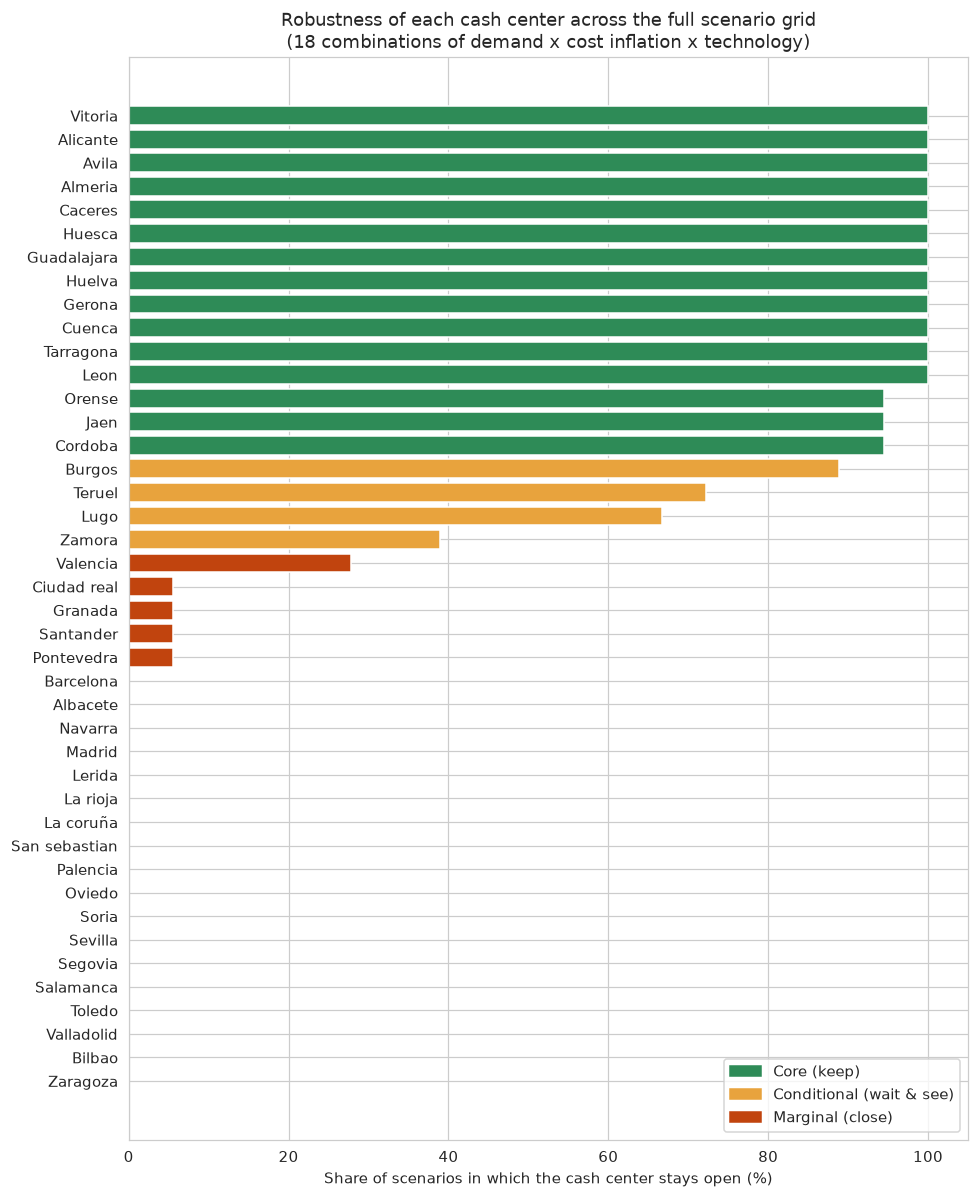

classification
Marginal (close)            23
Core (keep)                 15
Conditional (wait & see)     4
Name: count, dtype: int64


In [31]:
fig, ax = plt.subplots(figsize=(9, 11))
colors_map = {'Core (keep)': '#2e8b57', 'Conditional (wait & see)': '#e8a33d', 'Marginal (close)': '#c1440e'}
bar_colors = robustness_table['classification'].map(colors_map)
ax.barh(robustness_table['city'], robustness_table['open_share'] * 100, color=bar_colors)
ax.set_xlabel('Share of scenarios in which the cash center stays open (%)')
ax.set_title('Robustness of each cash center across the full scenario grid\n'
              f'({n_scenarios} combinations of demand x cost inflation x technology)')
ax.invert_yaxis()
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=l) for l, c in colors_map.items()]
ax.legend(handles=handles, loc='lower right')
plt.tight_layout()
plt.show()

print(robustness_table['classification'].value_counts())

# Interpretation of the robustness bar chart

The bar chart shows how frequently each cash center remains open across the full scenario grid. The colors distinguish between core, conditional, and marginal locations.

**Core locations** remain open in at least 90% of the scenarios. These cash centers form the robust backbone of the network. For example, locations such as Vitoria, Alicante, Avila, Almeria, and Caceres remain open in almost all scenarios. This suggests that they are strategically important facilities and should generally be retained, even if demand declines, costs increase, or new delivery technologies are adopted.

**Conditional locations** are selected only under some future assumptions. Locations such as Burgos, Teruel, Lugo, and Zamora are therefore more sensitive to changes in demand, cost inflation, and technology adoption. These sites should not be subject to immediate irreversible investment decisions. Instead, CashLog should monitor them regularly and follow a wait-and-see strategy.

**Marginal locations** are open in less than 30% of the scenarios. This means that they are not required in most future network configurations and can be considered closure candidates. However, they should not automatically be closed without further managerial review, because there may be special reasons to keep them, such as regulation, service-level requirements, or local strategic importance.

Overall, the bar chart translates the scenario analysis into clear managerial actions: core locations should be protected, conditional locations should be monitored, and marginal locations should be evaluated as potential closure candidates.

/tmp/ipykernel_2260/232062566.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grid_df, x=col, y='n_open', ax=ax, palette='Blues')
/tmp/ipykernel_2260/232062566.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grid_df, x=col, y='n_open', ax=ax, palette='Blues')
/tmp/ipykernel_2260/232062566.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grid_df, x=col, y='n_open', ax=ax, palette='Blues')


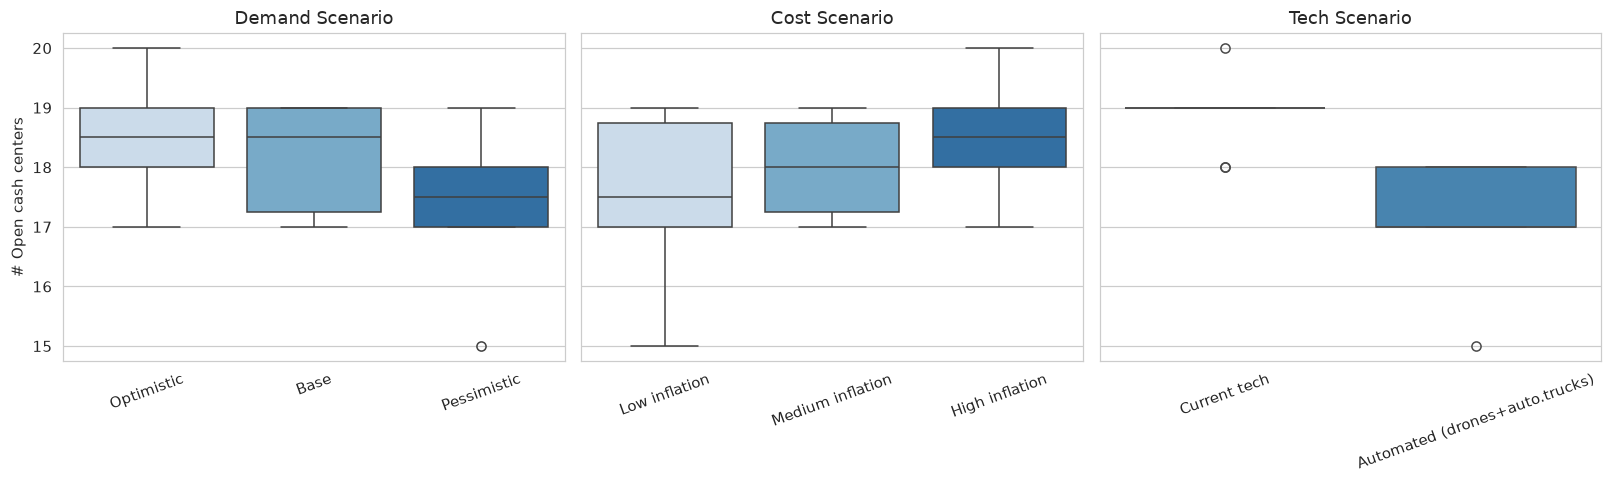

In [32]:

# Cost & network-size distribution across the scenario grid, split by dimension
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, col in zip(axes, ['demand_scenario', 'cost_scenario', 'tech_scenario']):
    sns.boxplot(data=grid_df, x=col, y='n_open', ax=ax, palette='Blues')
    ax.set_xlabel('')
    ax.set_title(col.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=20)
axes[0].set_ylabel('# Open cash centers')
plt.tight_layout()
plt.show()

# Interpretation of network-size distributions across scenario dimensions

The boxplots summarize how the number of open cash centers changes across the three main uncertainty dimensions: demand, cost inflation, and delivery technology.

**Demand scenario.**  
Under the pessimistic demand scenario, the number of open cash centers tends to be slightly lower. This is expected because lower cash demand reduces the number of required deliveries and allows some consolidation of the network. However, the network does not collapse even under a strong demand decline. This suggests that declining cash usage reduces capacity requirements, but geography and coverage constraints still make many cash centers necessary.

**Cost scenario.**  
As cost inflation increases, the number of open cash centers tends to increase. At first, this may seem counterintuitive. However, when transportation costs become more expensive, serving distant regions from fewer cash centers becomes less attractive. In this situation, the model may prefer a more decentralized network with more open cash centers in order to reduce delivery distances. Therefore, cost inflation increases the total cost level, but it can also make decentralization more valuable.

**Technology scenario.**  
Under technology adoption, especially in the automated scenario, the network tends to require fewer open cash centers. This is because autonomous trucks reduce labor-related shift costs and make transportation cheaper. As a result, the model can serve the network more efficiently with fewer facilities.

Overall, the boxplots show that demand decline and automation tend to support network consolidation, while cost inflation can push the network toward decentralization. This confirms that the optimal number of cash centers depends not only on demand volume, but also on the relative trade-off between fixed facility costs and transportation costs.

## 6. Conclusion & Recommendations

**1. Demand uncertainty.** Even in the pessimistic scenario (−8%/yr cash-usage decline over 5 years), the network does not collapse dramatically. Lower demand reduces the number of required deliveries and shifts, but many cash centers remain necessary because of geographic coverage requirements. This suggests that CashLog does not need an immediate large-scale network closure, but the number of required shifts per cash center should be monitored as a leading indicator for future consolidation decisions.

**2. Wages & fuel.** Cost inflation mainly increases the total cost level, while the network structure changes only stepwise. In the joint cost-inflation sweep, the number of open cash centers remains stable at 19 up to around 30% inflation and increases to 20 only at higher inflation levels. This happens because higher transportation costs make long-distance service more expensive, so a slightly more decentralized network can become attractive. The tornado analysis also shows that the network is more sensitive to wage-related shift costs than to fuel-related driving costs. Therefore, labor cost management and driver availability are more important strategic risks than fuel-price changes alone.

**3. Technology.** New delivery technologies reduce total network cost and slightly support network consolidation. Drone delivery has a limited but positive effect because it is only feasible for short-distance and low-demand routes; under this assumption, it reduces total cost by about 5.7% and lowers the number of open cash centers from 19 to 18. Autonomous trucks have a stronger impact because they affect the whole network and directly reduce the labor-related component of transportation costs. They reduce total cost by about 28.8%. The combined technology scenario creates the largest saving, around 32.1%, and reduces the network to 17 open cash centers.

**4. Robust recommendation.** The cash centers classified as Core locations, meaning they are open in at least 90% of the 18 scenario combinations, form the robust backbone of the network and should generally be retained. Conditional locations should be reviewed regularly as part of a rolling planning process, because their value depends on how demand, costs, and technology evolve. Marginal locations should be treated as closure candidates, but final closure decisions should still consider service-level requirements, regulation, regional coverage, and one-off transition costs.

**Caveats / limitations.** This analysis treats each scenario as a static snapshot rather than a true multi-year dynamic model with switching costs for opening or closing cash centers. It also assumes uniform demand decline and cost inflation across all regions, even though these factors may vary geographically in practice. Technology adoption is modeled as an immediate scenario switch, while in reality drones and autonomous trucks would likely be introduced gradually. A natural extension would be a multi-period stochastic optimization model or a Monte Carlo simulation of demand, cost, and technology trajectories.